If you have not yet downloaded the data and install the dependent repositories (`sensorium_2023`, `neuralpredictors`, `nnfabrik` and `mei`), please check the notebook `start-data-model.ipynb`.

In [1]:
seed = 111
random_seed = 111

In [2]:
# for auto-reloading external modules
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from matplotlib.colors import ListedColormap
import seaborn as sns
import re
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance
from scipy.stats import linregress, pearsonr
from collections import Counter
import h5py
# import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_poisson_deviance, make_scorer
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

import sys
sys.path.append('./src/sensorium_2023')
sys.path.append('./src/neuralpredictors')
sys.path.append('./src/nnfabrik')
from nnfabrik.utility.nn_helpers import set_random_seed
set_random_seed(seed)
from sensorium.datasets.mouse_video_loaders import mouse_video_loader
from sensorium.utility.scores import get_correlations, get_signal_correlations, model_predictions_align, get_responses_align, generate_2d_binned_average
from nnfabrik.builder import get_trainer
from sensorium.models.make_model import make_video_model

In [4]:
# for plot figures
plt.rcParams.update({'figure.max_open_warning': 0})
#Output matplotlib figure to SVG with text as text, not curves
plt.rcParams['svg.fonttype'] = 'none'
# axis spine
#use it like: adjust_spines(ax, ['left', 'bottom'])
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 2))  # outward by 2 points
            #spine.set_smart_bounds(True)
        else:
            spine.set_color('none')  # don't draw spine
    # turn off ticks where there is no spine
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        # no yaxis ticks
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
        # no xaxis ticks
        ax.xaxis.set_ticks([])

# Load Data

In [5]:
paths = [
    './data/franke_lab/qiu_2026/' + '/dynamic29163-4-4-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-18-4-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28712-3-8-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-6-5-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-5-8-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-19-9-Fluorescence-7b721b-v4a/',
    # four scans with limited training data (fewer than ```120``` trials)
    './data/franke_lab/qiu_2026/' + '/dynamic28188-17-2-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic29163-2-7-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-16-5-Fluorescence-7b721b-v4a/',
    './data/franke_lab/qiu_2026/' + '/dynamic28188-16-3-Fluorescence-7b721b-v4a/',
] 
neuron_ids_paths = [
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-4-4-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-18-4-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28712-3-8-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-6-5-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-5-8-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-19-9-Fluorescence-7b7_neurons_fluor_good.npy',
    # four scans with limited training data (fewer than ```120``` trials)
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-17-2-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic29163-2-7-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-16-5-Fluorescence-7b7_neurons_fluor_good.npy',
    './data/franke_lab/qiu_2026/data-quality'+'/dynamic28188-16-3-Fluorescence-7b7_neurons_fluor_good.npy',
]

print("Loading data..")
data_loader_config = {'batch_size': 3} # 7
data_loaders = mouse_video_loader(
    paths=paths,
    neuron_ids=[np.load(temp) for temp in neuron_ids_paths],
    batch_size=data_loader_config['batch_size'], # 8
    # scale=1,
    # max_frame=None,
    # frames=data_loader_config['frames'], # 100
    subtract_response_min=True,
    # offset=-1,
    include_behavior=True,
    include_pupil_centers=True,
    cuda=True, # True
    # to_cut=data_loader_config['to_cut'],
    behavior_channels=[0,2],
    random_sample_within_snippet_flag=False, # True
    num_random_subsequence=3, # 40
    subsequence_length=100,
    sequence_length=300, # 300
    random_start=np.array([0, 100, 200]), # 200
) #behaviror: (puil size, pupil size change, locomotion) 

Loading data..


In [6]:
data_loaders

{np.str_('test'): {'dynamic29163-4-4-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed2e680>,
  'dynamic28188-18-4-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed98520>,
  'dynamic28712-3-8-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed980a0>,
  'dynamic29163-6-5-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed98910>,
  'dynamic29163-5-8-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed99900>,
  'dynamic28188-19-9-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabed98f40>,
  'dynamic28188-17-2-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabedac820>,
  'dynamic29163-2-7-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabedac370>,
  'dynamic28188-16-5-Fluorescence-7b721b-v4a': <torch.utils.data.dataloader.DataLoader at 0x7fcabedad090>,
  'dynamic28188-16-3-Fluo

In [7]:
print ('Show a batch of data:')
tier = 'train'
dataset_name = list(data_loaders['train'].keys())[0] # 'dynamic28188-18-4-Activity-a0e5a8'
# for batch in data_loaders[tier][dataset_name]:
#     pass
# #
# # each batch is a NameTuple, containing the images, neuronal responses, and the behavioral variables
# print(batch._fields)
# #
# # Inspecting the content of a batch
# for i, field in enumerate(batch._fields):
#     print(f"{field}, {batch[i].shape}")
# # what will get printed:
# # images: N images, channels, height, width
# # responses: N images, N neurons
# # behavior: N images, N=3 behaviors (pupil size, instantaneous change of pupil size, locomotion speed)
# # pupil_center: N images, N=2 eye position traces: horizontal and vertical eye position

Show a batch of data:


In [8]:
for ii,batch in enumerate(data_loaders[tier][dataset_name]):
    if ii<2:
        print (batch[0].shape)
    else:
        break

torch.Size([3, 3, 299, 36, 64])
torch.Size([3, 3, 299, 36, 64])


In [9]:
# 'oracle'
for ii,batch in enumerate(data_loaders['validation'][dataset_name]):
    if ii<2:
        print (batch[0].shape)
    else:
        break

torch.Size([1, 3, 299, 36, 64])
torch.Size([1, 3, 299, 36, 64])


In [10]:
# # 'live_test_main'
# for ii,batch in enumerate(data_loaders['test'][dataset_name]):
#     if ii<2:
#         print (batch[0].shape)
#     else:
#         break

In [11]:
# 'oracle'
for ii,batch in enumerate(data_loaders['validation'][dataset_name]):
    if ii<2:
        print (batch[1].shape)
    else:
        break

torch.Size([1, 3175, 299])
torch.Size([1, 3175, 299])


# Factorised 3D core and Gaussian readout

In [12]:
factorised_3D_core_dict = dict(
    input_channels=3, # 3
    hidden_channels=[64, 64, 64], # [32, 64, 128]
    spatial_input_kernel=(11,11),
    temporal_input_kernel=11,
    spatial_hidden_kernel=(5,5),
    temporal_hidden_kernel=5,
    stride=1,
    layers=3,
    gamma_input_spatial=10,
    gamma_input_temporal=0.01, 
    bias=True, 
    hidden_nonlinearities='elu', 
    x_shift=0, 
    y_shift=0,
    batch_norm=True, 
    laplace_padding=None,
    input_regularizer='LaplaceL2norm',
#     padding=True,
    padding=False,
    final_nonlin=True,
    independent_bn_bias=True,
#     pad_time=False,
    momentum=0.7
)

shifter_dict = dict(
    gamma_shifter=0,
    shift_layers=3,
    input_channels_shifter=2,
    hidden_channels_shifter=5,
)


readout_dict = dict(
    bias=True,
    init_mu_range=0.1,
    init_sigma=0.3,
    gamma_readout=1.0,
    gauss_type='full',
    # grid_mean_predictor={
    #     'type': 'cortex',
    #     'input_dimensions': 2,
    #     'hidden_layers': 1,
    #     'hidden_features': 30,
    #     'final_tanh': True
    # },
    grid_mean_predictor=None,
    share_features=False,
    share_grid=False,
    shared_match_ids=None,
    gamma_grid_dispersion=0.0,
)

In [13]:
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=True, # True # False
    feature_latent_dim=2,
    position_encoding_flag=False,
    position_encoding_k=16,
)

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


In [14]:
factorised_3d_model

VideoFiringRateEncoder(
  (core): Factorized3dCore(
    (_input_weight_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (temporal_regularizer): DepthLaplaceL21d(
      (laplace): Laplace1d()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv_spatial): Conv3d(3, 64, kernel_size=(1, 11, 11), stride=(1, 1, 1))
        (conv_temporal): Conv3d(64, 64, kernel_size=(11, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer1): Sequential(
        (conv_spatial_1): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(1, 1, 1))
        (conv_temporal_1): Conv3d(64, 64, kernel_size=(5, 1, 1), stride=(1, 1, 1))
        (norm): BatchNorm3d(64, eps=1e-05, momentum=0.7, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0)
      )
      (layer2): Sequential(
        (conv_spatial_2): Conv3d(64, 64, kernel_size=(1, 5, 5), stride=(

In [15]:
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].feature_latent.shape)
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].feature_mlp)
# print (factorised_3d_model.readout['dynamic29163-4-4-Fluorescence-7b721b'].features.shape)

# Training

In [17]:
# train 1
feature_latent_flags = [False,]
unit_speed_flag = False
position_encoding_flag = False
# v05aa: explicit readout + no cortex coordinates + all 10 scans
# v05aaa: explicit readout + cortex coordinates + all 10 scans, for sharedmodel
#
# v05bb, v05cc, v05dd: transfer learning across animals
# v05bb: explicit readout + no cortex coordinates + 4 scans as a core for transfer learning
# v05cc: explicit readout + no cortex coordinates + train from sratch; v05dd: explicit readout + no cortex coordinates + transfer learning
#
# v05bbb, v05ccc, v05ddd: transfer learning across sessions for the same animal
# v05bbb: explicit readout + no cortex coordinates + 3 scan as a core for transfer learning across sessions for the same animal
# v05ccc: explicit readout + no cortex coordinates + train from sratch; v05ddd: explicit readout + no cortex coordinates + transfer learning from v05bbb
wandb_suffixes = ['v05aa']  # v05aa, v05aaa

for ii in range(len(feature_latent_flags)):
    set_random_seed(seed)
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    
    # wandb_project = "data_v1_nexport_eric_"
    wandb_project = "data_retina_sc_multiple_v4a_fluor_"
    wandb_name = f'model_fac3d_seed_{random_seed}_' + wandb_suffixes[ii]  # f'model_fac3d_seed_{random_seed}_v1e-rs1'
    trainer_config = {}
    trainer_config['wandb_model_config'] = {'core_dict' : factorised_3D_core_dict, }

    checkpoint_save_path = f'./out/' + wandb_project + wandb_name # './out/factorised_3d_model_'
    trainer_config = {
        'dataloaders' : data_loaders,
        'seed' : random_seed,
        'loss_accum_batch_n' : 1,
        # 'use_wandb' : False,
        'verbose': True,
        'lr_decay_steps': 4,
        'lr_init': 0.005,
        'device' : f"cuda:0",
        'detach_core' : False,
        #'chpt_save_step': 1,
        #'max_iter': 2,
        'checkpoint_save_path': checkpoint_save_path,
        'validation_str': "validation", # default: "oracle"
        'unit_speed_flag': unit_speed_flag,
        'unit_speed_scale': 0,
                     }
    trainer_config.update({
        'use_wandb': False,
        'wandb_project': wandb_project,
        'wandb_entity': "qyrixpress",
        'wandb_name': wandb_name,
                     })
    trainer_config['wandb_dataset_config'] = {'data_loader_config' : data_loader_config}

    trainer_fn = "sensorium.training.video_training_loop.standard_trainer"
    trainer = get_trainer(trainer_fn=trainer_fn, 
                     trainer_config=trainer_config)

    # validation_score, trainer_output, state_dict = trainer(factorised_3d_model)

/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Evaluation 

In [18]:
from sensorium.utility.scores import Custom_Cmaps
custom_cmaps = Custom_Cmaps()
custom_cmap1 = custom_cmaps.Custom_Cmap1()
custom_cmap2 = custom_cmaps.Custom_Cmap2()

# from torch.func import jacfwd, vmap
# modelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + 'v05aa' + '.pth' 
device = torch.device("cuda:0") # torch.device("cuda:0") # "cuda:0", torch.device("cpu")
cuda_flag = False if device == torch.device("cpu") else True
print (f'cuda_flag: {cuda_flag}')
datakeys = list(data_loaders['train'].keys())
print (datakeys)
# datakey = list(data_loaders['train'].keys())[0]

cuda_flag: True
['dynamic29163-4-4-Fluorescence-7b721b-v4a', 'dynamic28188-18-4-Fluorescence-7b721b-v4a', 'dynamic28712-3-8-Fluorescence-7b721b-v4a', 'dynamic29163-6-5-Fluorescence-7b721b-v4a', 'dynamic29163-5-8-Fluorescence-7b721b-v4a', 'dynamic28188-19-9-Fluorescence-7b721b-v4a', 'dynamic28188-17-2-Fluorescence-7b721b-v4a', 'dynamic29163-2-7-Fluorescence-7b721b-v4a', 'dynamic28188-16-5-Fluorescence-7b721b-v4a', 'dynamic28188-16-3-Fluorescence-7b721b-v4a']


In [19]:
all_cluster_info = pd.read_csv('./data' + '/GMM-cluster-info.csv')
all_cluster_info

,animal_id,session_id,scan_id,unit_id,clusterID_depth,clusterID_sorted,on_off_idx,transient_idx,depth
0,28188,10,8,8,13,35.0,0.047062,0.409816,30.0
1,28188,10,8,10,8,37.0,0.003694,0.292615,30.0
2,28188,10,8,11,8,37.0,-0.082364,0.893915,30.0
3,28188,10,8,12,15,10.0,-0.176969,0.560842,30.0
4,28188,10,8,14,8,37.0,0.473766,0.872893,30.0
...,...,...,...,...,...,...,...,...,...
71016,29163,8,7,3420,44,34.0,0.668651,0.121337,160.0
71017,29163,8,7,3594,45,8.0,-0.227747,0.326322,160.0
71018,29163,8,7,3699,44,34.0,0.576408,0.202777,160.0
71019,29163,8,7,5368,44,34.0,0.728594,0.510301,180.0


In [20]:
print (np.unique(all_cluster_info.loc[:, 'clusterID_depth'].values)) # cluster IDs sorted by depth
# clusterID sorted according to their correlation with the  BadenBerensFranke2016 clusters (they ordered clusters starting with OFF and ending with slow ON)
print (np.unique(all_cluster_info.loc[:, 'clusterID_sorted'].values)) 

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]


In [21]:
all_cluster_clean = pd.read_hdf('./data' + '/sc_retinal_axons_clusters_clean.h5', key='df')
all_cluster_clean

,animal_id,session_id,scan_id,unit_id,depth,cluster_IDs,clusterID
0,28188,10,8,8,30.0,4,4
4,28188,10,8,14,30.0,0,0
5,28188,10,8,15,30.0,4,4
7,28188,10,8,17,30.0,16,16
8,28188,10,8,20,30.0,4,4
...,...,...,...,...,...,...,...
71016,29163,8,7,3420,160.0,1,1
71017,29163,8,7,3594,160.0,33,33
71018,29163,8,7,3699,160.0,3,3
71019,29163,8,7,5368,180.0,3,3


In [22]:
mismatch = all_cluster_clean[all_cluster_clean['cluster_IDs'] != all_cluster_clean['clusterID']]
print(mismatch)

Empty DataFrame
Columns: [animal_id, session_id, scan_id, unit_id, depth, cluster_IDs, clusterID]
Index: []


## CC - explicit readout

In [102]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    val_correlation = get_correlations(
            factorised_3d_model, data_loaders["validation"], device=device, as_dict=False, per_neuron=False
        )
    print(f'Feature_latent_flags {feature_latent_flags[ii]}, val_correlation: {val_correlation:.4f}')
    evaluation_hashes_unique, single_trial_corrs, mean_corrs = get_signal_correlations(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='clip', evaluation_hashes_unique=['5zQTb77qI+ig8rigx1XU', \
        '7UETOWO5Z8aWuHDBJ2GG', 'GjCMo2GkJp6y5vricadg', 'KXdTNAGMo1gCWz2Ge8zr', 'Oup5uAZxF2G7zEJkT+ui', 'ecUQJtcERZJGdqza1k7h'],
        device=device, as_dict=True, per_neuron=True,
    )
    # print (f'single-trial-corr: {np.mean(single_trial_corrs[datakey]):.4f}')
    # print (f'mean-corr: {np.mean(mean_corrs[datakey]):.4f}')
    print (f'evaluation_hashes_unique: {evaluation_hashes_unique}')

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


Feature_latent_flags False, val_correlation: 0.5180
evaluation_hashes_unique: ['5zQTb77qI+ig8rigx1XU', '7UETOWO5Z8aWuHDBJ2GG', 'GjCMo2GkJp6y5vricadg', 'KXdTNAGMo1gCWz2Ge8zr', 'Oup5uAZxF2G7zEJkT+ui', 'ecUQJtcERZJGdqza1k7h']


/tmp/ipykernel_1647/2015389869.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=45)
/tmp/ipykernel_1647/2015389869.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=45)


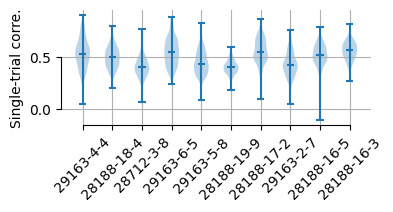

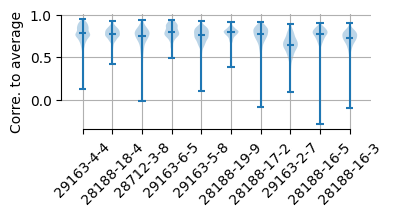

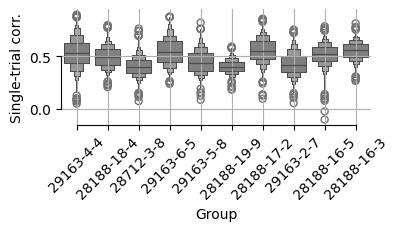

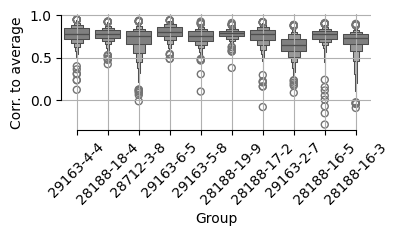

In [103]:
templabels = [datakey[7:-24] for datakey in datakeys]
temp_means = [np.mean(single_trial_corrs[datakey]) for datakey in datakeys]
temp_stds = [np.std(single_trial_corrs[datakey], ddof=1) for datakey in datakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([single_trial_corrs[datakey] for datakey in datakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,5.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=45)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Single-trial corre.')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_single_trial_correlation.svg")

temp_means = [np.mean(mean_corrs[datakey]) for datakey in datakeys]
temp_stds = [np.std(mean_corrs[datakey], ddof=1) for datakey in datakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([mean_corrs[datakey] for datakey in datakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,5.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=45)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Corre. to average')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_mean_correlation.svg")

# collect values into long-form dataframe
records = []
for i, datakey in enumerate(datakeys):
    for val in single_trial_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=45)
ax.set_ylabel("Single-trial corr.")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_single_correlation_boxenplot.svg")

# collect values into long-form dataframe
records = []
for i, datakey in enumerate(datakeys):
    for val in mean_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=45)
ax.set_ylabel("Corr. to average")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_mean_correlation_boxenplot.svg")

In [108]:
np.median(np.hstack([single_trial_corrs[datakey] for datakey in datakeys])), np.median(np.hstack([mean_corrs[datakey] for datakey in datakeys]))

(np.float32(0.5002645), np.float32(0.7614475))

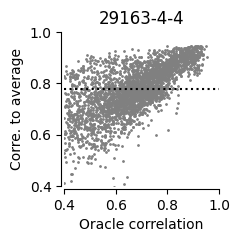

In [27]:
# scatter plot for one scan
ii = 0
datakey = datakeys[ii]
neuron_ids = np.load(neuron_ids_paths[ii])

# corr_fluor_path = '/project/notebooks/retina-sc' + '/dynamic29163-4-4_corr_fluor.npy'
corr_fluor_path = '/mnt/scratch09/yongrong/datahub/retina-sc/axon-v4a/data-quality' + '/dynamic29163-4-4-Fluorescence-7b7_corr_fluor.npy'
corr_fluor = np.load(corr_fluor_path)

fig, ax= plt.subplots(figsize=(2,2))
ax.scatter((corr_fluor[:])[neuron_ids], mean_corrs[datakey], s=1, color='gray')
ax.axhline(y=np.mean(mean_corrs[datakey]), linestyle=':', color='k')
ax.set_xlim(0.4, 1)
ax.set_ylim(0.4, 1)
ax.set_xlabel('Oracle correlation')
ax.set_ylabel('Corre. to average')
ax.set_title(datakey[7:-24])
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/mean_correlation_vs_oracle_correlation_ms.svg")

Number of axonal boutons: 17272


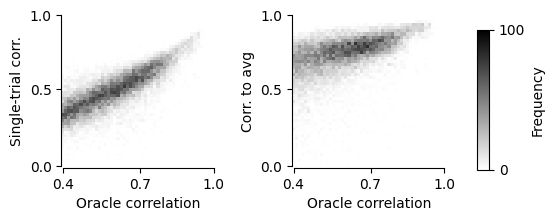

In [38]:
# histogram 
corr_fluor_paths = ['/mnt/scratch09/yongrong/datahub/retina-sc/axon-v4a/data-quality/'+datakey[:-7]+'_corr_fluor.npy'  for datakey in datakeys]
corr_fluors = [np.load(corr_fluor_path) for corr_fluor_path in corr_fluor_paths]
neuron_ids = [np.load(neuron_ids_path) for neuron_ids_path in neuron_ids_paths]
corr_fluors = [corr_fluor[neuron_id] for neuron_id,corr_fluor in zip(neuron_ids, corr_fluors)]
corr_fluors = np.hstack(corr_fluors)
print (f'Number of axonal boutons: {len(corr_fluors)}')

hist_range = [[0.4, 1.0], [0.0, 1.0]]
bins = 50
show_min = 0
show_max = 100 # 0.004
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))
x, y = np.copy(corr_fluors), np.hstack([single_trial_corrs[datakey] for datakey in datakeys])
weights = np.ones_like(x) # /float(len(x))
hist_data, _, _ = np.histogram2d(x, y, bins=bins, range=hist_range, weights=weights)
hist_data = hist_data.T
im = ax[0].imshow(hist_data, interpolation='nearest', origin='lower',cmap='gray_r',vmin=show_min, vmax=show_max) # jet, viridis
ax[0].set_xlabel('Oracle correlation')
ax[0].set_ylabel('Single-trial corr.')

x, y = np.copy(corr_fluors), np.hstack([mean_corrs[datakey] for datakey in datakeys])
weights = np.ones_like(x) # /float(len(x))
hist_data, _, _ = np.histogram2d(x, y, bins=bins, range=hist_range, weights=weights)
hist_data = hist_data.T
im = ax[1].imshow(hist_data, interpolation='nearest', origin='lower',cmap='gray_r',vmin=show_min, vmax=show_max)
ax[1].set_xlabel('Oracle correlation')
ax[1].set_ylabel('Corr. to avg')

for ii in range(2):
    ax[ii].set_xticks([0, int(bins/2), bins-1])
    ax[ii].set_xticklabels([hist_range[0][0], np.sum(hist_range[0])/2, hist_range[0][1]])
    ax[ii].set_yticks([0, int(bins/2), bins-1])
    ax[ii].set_yticklabels([hist_range[1][0], np.sum(hist_range[1])/2, hist_range[1][1]])
    
sns.despine(trim=True)
fig.subplots_adjust(right=0.83)
cbar_ax = fig.add_axes([0.85, 0.1, 0.02, 0.7])
ticks=[show_min, show_max]
cbar = fig.colorbar(im, cax=cbar_ax, ticks=ticks)
cbar.set_label("Frequency")
# plt.savefig(f"out_result/hist_single_trial_and_mean_correlation_vs_oracle_correlation_ms.svg")

In [49]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    # val_correlation = get_correlations(
    #         factorised_3d_model, data_loaders["validation"], device=device, as_dict=False, per_neuron=False
    #     )
    # print(f'Feature_latent_flags {feature_latent_flags[ii]}, val_correlation: {val_correlation:.4f}')
    evaluation_hashes_unique, single_trial_corrs, mean_corrs = get_signal_correlations(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='presentmoviearray', 
        evaluation_hashes_unique=[
            "fQnZOaH1tdWxRyb3ipGZ", # chirp
            # "0N5anjqjPcKoH66W9mzf", # moving_bar
        ], 
        device=device, 
        datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],],  # [datakeys[0], ]
        as_dict=True, per_neuron=True
    )
    # print (f'single-trial-corr: {np.mean(single_trial_corrs[datakey]):.4f}')
    # print (f'mean-corr: {np.mean(mean_corrs[datakey]):.4f}')
    print (f'evaluation_hashes_unique: {evaluation_hashes_unique}')

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


evaluation_hashes_unique: ['fQnZOaH1tdWxRyb3ipGZ']


/tmp/ipykernel_51334/167756322.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=30)


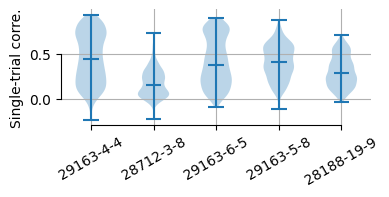

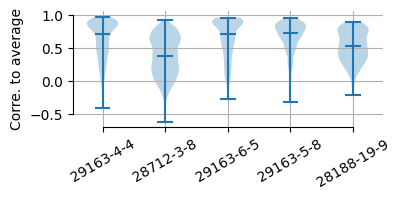

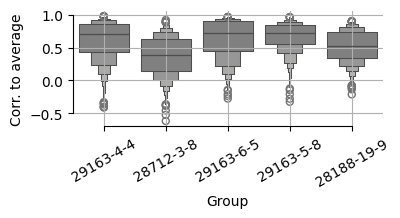

In [53]:
tempdatakeys = [datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],]
templabels = [datakey[7:-24] for datakey in tempdatakeys]
temp_means = [np.mean(single_trial_corrs[datakey]) for datakey in tempdatakeys]
temp_stds = [np.std(single_trial_corrs[datakey], ddof=1) for datakey in tempdatakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([single_trial_corrs[datakey] for datakey in tempdatakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,4.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=30)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Single-trial corre.')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_single_trial_correlation_chirp.svg")

temp_means = [np.mean(mean_corrs[datakey]) for datakey in tempdatakeys]
temp_stds = [np.std(mean_corrs[datakey], ddof=1) for datakey in tempdatakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([mean_corrs[datakey] for datakey in tempdatakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,4.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=30)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Corre. to average')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_mean_correlation_chirp.svg")

# collect values into long-form dataframe
records = []
for i, datakey in enumerate(tempdatakeys):
    for val in mean_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=30)
ax.set_ylabel("Corr. to average")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_mean_correlation_chirp_boxenplot.svg")

In [54]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    # val_correlation = get_correlations(
    #         factorised_3d_model, data_loaders["validation"], device=device, as_dict=False, per_neuron=False
    #     )
    # print(f'Feature_latent_flags {feature_latent_flags[ii]}, val_correlation: {val_correlation:.4f}')
    evaluation_hashes_unique, single_trial_corrs, mean_corrs = get_signal_correlations(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='presentmoviearray', 
        evaluation_hashes_unique=[
            # "fQnZOaH1tdWxRyb3ipGZ", # chirp
            "0N5anjqjPcKoH66W9mzf", # moving_bar
        ], 
        device=device, 
        datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],],  # [datakeys[0], ]
        as_dict=True, per_neuron=True
    )
    # print (f'single-trial-corr: {np.mean(single_trial_corrs[datakey]):.4f}')
    # print (f'mean-corr: {np.mean(mean_corrs[datakey]):.4f}')
    print (f'evaluation_hashes_unique: {evaluation_hashes_unique}')

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


evaluation_hashes_unique: ['0N5anjqjPcKoH66W9mzf']


/tmp/ipykernel_51334/3726789099.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=30)


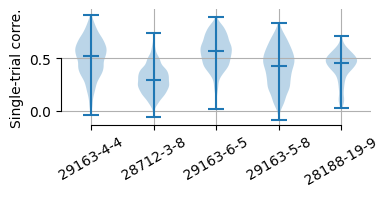

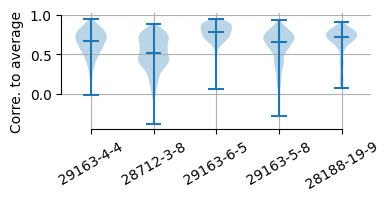

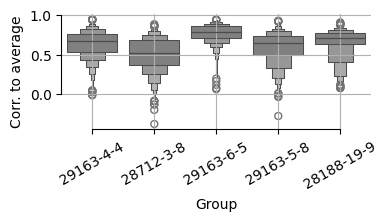

In [56]:
tempdatakeys = [datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],]
templabels = [datakey[7:-24] for datakey in tempdatakeys]
temp_means = [np.mean(single_trial_corrs[datakey]) for datakey in tempdatakeys]
temp_stds = [np.std(single_trial_corrs[datakey], ddof=1) for datakey in tempdatakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([single_trial_corrs[datakey] for datakey in tempdatakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,4.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=30)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Single-trial corre.')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_single_trial_correlation_moving_bar.svg")

temp_means = [np.mean(mean_corrs[datakey]) for datakey in tempdatakeys]
temp_stds = [np.std(mean_corrs[datakey], ddof=1) for datakey in tempdatakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
# ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
#             marker='o', color='k',linestyle='None',alpha=1, capsize=4)
# ax.set_xticks(np.arange(len(temp_means)).tolist())
ax.violinplot([mean_corrs[datakey] for datakey in tempdatakeys], showmeans=False, showmedians=True)
ax.set_xticks(np.arange(1, len(temp_means)+1).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,4.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=30)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Corre. to average')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_mean_correlation_moving_bar.svg")

# collect values into long-form dataframe
records = []
for i, datakey in enumerate(tempdatakeys):
    for val in mean_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=30)
ax.set_ylabel("Corr. to average")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_mean_correlation_moving_bar_boxenplot.svg")

In [41]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    _, _, mean_corrs_c = get_signal_correlations(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='presentmoviearray', 
        evaluation_hashes_unique=[
            "fQnZOaH1tdWxRyb3ipGZ", # chirp
            # "0N5anjqjPcKoH66W9mzf", # moving_bar
        ], 
        device=device, 
        datakeys=[datakeys[0], ],  # [datakeys[0], ]
        as_dict=True, per_neuron=True
    )
    _, _, mean_corrs_m = get_signal_correlations(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='presentmoviearray', 
        evaluation_hashes_unique=[
            # "fQnZOaH1tdWxRyb3ipGZ", # chirp
            "0N5anjqjPcKoH66W9mzf", # moving_bar
        ], 
        device=device, 
        datakeys=[datakeys[0], ],  # [datakeys[0], ]
        as_dict=True, per_neuron=True
    )

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


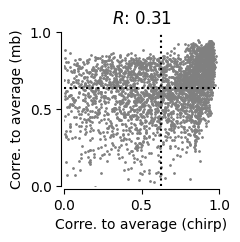

In [42]:
datakey = datakeys[0]
mean_corrs_list = [mean_corrs_c[datakey], mean_corrs_m[datakey]]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(2,2))
# ax.plot((0,1),(0,1), color='gray')
ax.scatter(mean_corrs_list[0], mean_corrs_list[1], s=1, color='gray')
ax.axvline(x=np.mean(mean_corrs_list[0]), linestyle=':', color='k')
ax.axhline(y=np.mean(mean_corrs_list[1]), linestyle=':', color='k')
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_xlabel('Corre. to average (chirp)')
ax.set_ylabel('Corre. to average (mb)')
ax.set_title(r'$R$' + f': {pearsonr(mean_corrs_list[0], mean_corrs_list[1])[0]:.2f}')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/chirp_vs_moving_bar_mean_cc_ms.svg")

## Response traces - explicit readout

In [29]:
datakey = list(data_loaders['train'].keys())[0]
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    # responses_aligns: a  dict of responses_align
    # responses_align: a list of array, each array corresponds to reponses to one condition_hash,
    # array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
    evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='clip', evaluation_hashes_unique=['5zQTb77qI+ig8rigx1XU', \
        '7UETOWO5Z8aWuHDBJ2GG', 'GjCMo2GkJp6y5vricadg', 'KXdTNAGMo1gCWz2Ge8zr', 'Oup5uAZxF2G7zEJkT+ui', 'ecUQJtcERZJGdqza1k7h'],
        device=device, pad_responses=True)

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


In [30]:
unit_ids = np.array([4658, 3507, 1510, 5302,  703, 4085, 5250, 2207, 2606,  456, 2233, 2080, 3402, 5670, 5097, 2291])

unit_ids position(index) in the good_quality_neurons: [1982 1495  467 2473  239 1733 2435  990 1310  162 1014  904 1469 2750
 2305 1064]


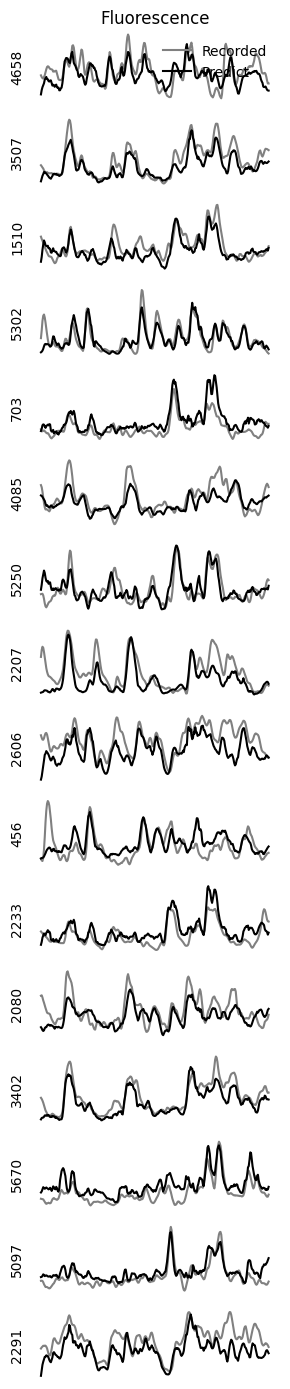

In [32]:
datakey = datakeys[0]
temphashindex=1 # 5,, we have 6 condition_hashes
np.random.seed(6) # 6
# tempneurons = np.random.choice(responses_aligns[datakey][temphashindex].shape[2], size=3, replace=False)
# tempneurons = np.random.choice(np.where(mean_corrs[datakey]>0.85)[0], size=5, replace=False) # 3
# tempneurons = np.random.choice(len(behav_dict['mean_corrs']), size = 5, replace=False)
# unit_ids' position(index) in the good_quality_neurons
unit_indice = np.array([np.where(data_loaders["train"][datakey].dataset.neurons.unit_ids==xx)[0][0] for xx in unit_ids])
print (f'unit_ids position(index) in the good_quality_neurons: {unit_indice}')
tempneurons = np.copy(unit_indice)
nrows=len(tempneurons)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(3,int(nrows/1.1)))
for ii in range(nrows):
    tempind = tempneurons[ii]
    tempresponses = responses_aligns[datakey][temphashindex][:,:,tempind]
    temppredictions = predictions_aligns[datakey][temphashindex][:,:,tempind]
    axes[ii].plot(np.mean(tempresponses, axis=0),color='gray',linestyle='-',label='Recorded')
    axes[ii].plot(np.mean(temppredictions, axis=0),color='k',linestyle='-',label='Predict')
    axes[ii].spines['left'].set_visible(False)
    axes[ii].spines['bottom'].set_visible(False)
    axes[ii].spines['right'].set_visible(False)
    axes[ii].spines['top'].set_visible(False)
    axes[ii].set_xticks([])
    axes[ii].set_yticks([])
    # axes[ii].set_ylabel(f"{behav_dict['mean_corrs'][tempind]:.2f}")
    axes[ii].set_ylabel(f'{unit_ids[ii]}')
    axes[0].legend(loc='best',frameon=False)
    axes[0].set_title('Fluorescence')
plt.tight_layout()
# plt.savefig(f"out_result/response_{datakey[7:-24]}_test{temphashindex}_ms.svg")

In [33]:
factorised_3d_model.eval()
# responses_aligns: a  dict of responses_align
# responses_align: a list of array, each array corresponds to reponses to one condition_hash,
# array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
    factorised_3d_model, data_loaders, tier='test', stimulus_type="presentmoviearray",
    evaluation_hashes_unique=[
        "fQnZOaH1tdWxRyb3ipGZ", # chirp
        "0N5anjqjPcKoH66W9mzf", # moving_bar
    ], 
    device=device,
    datakeys=[datakey,], # [datakey,]
    pad_responses=True,
)

unit_ids position(index) in the good_quality_neurons: [1982 1495  467 2473  239 1733 2435  990 1310  162 1014  904 1469 2750
 2305 1064]


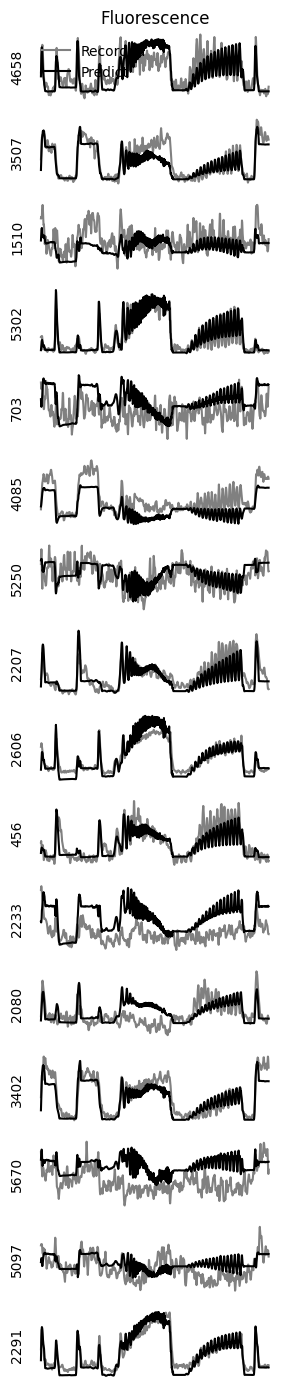

In [36]:
temphashindex=0 # 5,, we have 6 condition_hashes
# np.random.seed(6) # 6
# tempneurons = np.random.choice(responses_aligns[datakey][temphashindex].shape[2], size=3, replace=False)
# tempneurons = np.random.choice(np.where(mean_corrs[datakey]>0.85)[0], size=5, replace=False) # 3
# tempneurons = np.random.choice(len(behav_dict['mean_corrs']), size = 5, replace=False)
# unit_ids' position(index) in the good_quality_neurons
unit_indice = np.array([np.where(data_loaders["train"][datakey].dataset.neurons.unit_ids==xx)[0][0] for xx in unit_ids])
print (f'unit_ids position(index) in the good_quality_neurons: {unit_indice}')
tempneurons = np.copy(unit_indice)
nrows=len(tempneurons)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(3,int(nrows/1.1)))
for ii in range(nrows):
    tempind = tempneurons[ii]
    tempresponses = responses_aligns[datakey][temphashindex][:,:,tempind]
    temppredictions = predictions_aligns[datakey][temphashindex][:,:,tempind]
    axes[ii].plot(np.mean(tempresponses, axis=0),color='gray',linestyle='-',label='Recorded')
    axes[ii].plot(np.mean(temppredictions, axis=0),color='k',linestyle='-',label='Predict')
    axes[ii].spines['left'].set_visible(False)
    axes[ii].spines['bottom'].set_visible(False)
    axes[ii].spines['right'].set_visible(False)
    axes[ii].spines['top'].set_visible(False)
    axes[ii].set_xticks([])
    axes[ii].set_yticks([])
    # axes[ii].set_ylabel(f"{behav_dict['mean_corrs'][tempind]:.2f}")
    axes[ii].set_ylabel(f'{unit_ids[ii]}')
    axes[0].legend(loc='best',frameon=False)
    axes[0].set_title('Fluorescence')
plt.tight_layout()
# plt.savefig(f"out_result/response_{datakey[7:-24]}_chirp_ms.svg")

unit_ids position(index) in the good_quality_neurons: [1982 1495  467 2473  239 1733 2435  990 1310  162 1014  904 1469 2750
 2305 1064]


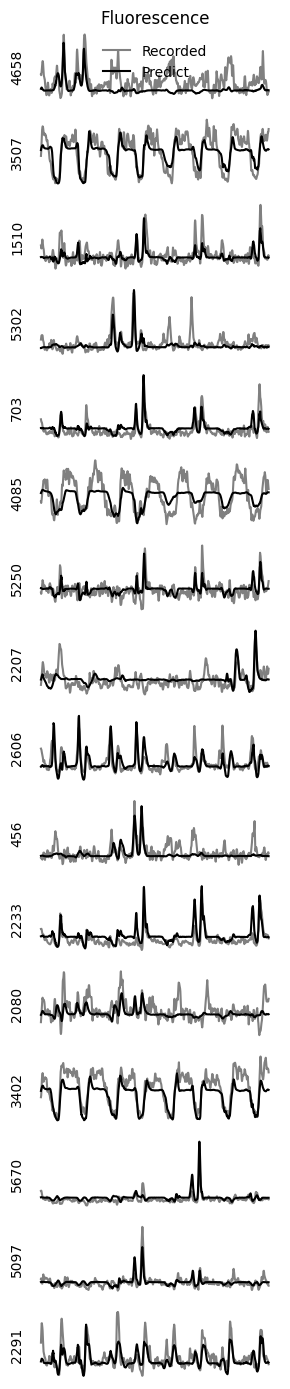

In [38]:
temphashindex=1 # 5,, we have 6 condition_hashes
# np.random.seed(6) # 6
# tempneurons = np.random.choice(responses_aligns[datakey][temphashindex].shape[2], size=3, replace=False)
# tempneurons = np.random.choice(np.where(mean_corrs[datakey]>0.85)[0], size=5, replace=False) # 3
# tempneurons = np.random.choice(len(behav_dict['mean_corrs']), size = 5, replace=False)
# unit_ids' position(index) in the good_quality_neurons
unit_indice = np.array([np.where(data_loaders["train"][datakey].dataset.neurons.unit_ids==xx)[0][0] for xx in unit_ids])
print (f'unit_ids position(index) in the good_quality_neurons: {unit_indice}')
tempneurons = np.copy(unit_indice)
nrows=len(tempneurons)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(3,int(nrows/1.1)))
for ii in range(nrows):
    tempind = tempneurons[ii]
    tempresponses = responses_aligns[datakey][temphashindex][:,:,tempind]
    temppredictions = predictions_aligns[datakey][temphashindex][:,:,tempind]
    axes[ii].plot(np.mean(tempresponses, axis=0),color='gray',linestyle='-',label='Recorded')
    axes[ii].plot(np.mean(temppredictions, axis=0),color='k',linestyle='-',label='Predict')
    axes[ii].spines['left'].set_visible(False)
    axes[ii].spines['bottom'].set_visible(False)
    axes[ii].spines['right'].set_visible(False)
    axes[ii].spines['top'].set_visible(False)
    axes[ii].set_xticks([])
    axes[ii].set_yticks([])
    # axes[ii].set_ylabel(f"{behav_dict['mean_corrs'][tempind]:.2f}")
    axes[ii].set_ylabel(f'{unit_ids[ii]}')
    axes[0].legend(loc='best',frameon=False)
    axes[0].set_title('Fluorescence')
plt.tight_layout()
# plt.savefig(f"out_result/response_{datakey[7:-24]}_moving_bar_ms.svg")

In [177]:
# # save data for following DS and OS analysis
# feature_latent_flags = [False]
# unit_speed_flag = False
# position_encoding_flag = False
# wandb_suffixes = ['v05aa']
# for ii in range(len(feature_latent_flags)):
#     tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
#     factorised_3d_model = make_video_model(
#         data_loaders,
#         seed,
#         core_dict=factorised_3D_core_dict,
#         core_type='3D_factorised',
#         readout_dict=readout_dict.copy(),
#         readout_type='gaussian',               
#         use_gru=False,
#         gru_dict=None,
#         use_shifter=True,
#         shifter_dict=shifter_dict,
#         shifter_type='MLP',
#         feature_latent_flag=feature_latent_flags[ii], # True # False
#         feature_latent_dim=2,
#         position_encoding_flag=position_encoding_flag,
#         position_encoding_k=16,
#     )
#     factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
#     factorised_3d_model.eval()

# # responses_aligns: a  dict of responses_align
# # responses_align: a list of array, each array corresponds to reponses to one condition_hash,
# # array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
# evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
#     factorised_3d_model, data_loaders, tier='test', stimulus_type="presentmoviearray",
#     evaluation_hashes_unique=[
#         # "fQnZOaH1tdWxRyb3ipGZ", # chirp
#         "0N5anjqjPcKoH66W9mzf", # moving_bar
#     ], 
#     device=device,
#     datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],], # [datakey,]
#     pad_responses=True,
# )
# print (responses_aligns['dynamic29163-4-4-Fluorescence-7b721b-v4a'][0].shape) # 3 repeats, 958 time points, 3175 neurons

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning:

Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored



In [ ]:
# import pickle 

# with open('out/model_seed_111_v05aa_mb_responses_aligns.pkl', 'wb') as ff:
#     pickle.dump(responses_aligns, ff)

# with open('out/model_seed_111_v05aa_mb_predictions_aligns.pkl', 'wb') as ff:
#     pickle.dump(predictions_aligns, ff)
        
# # with open('saved_dictionary.pkl', 'rb') as f:
# #     loaded_dict = pickle.load(f)

## Retinopy

In [20]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))

datakeys = list(data_loaders['train'].keys())
print (datakeys)

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


['dynamic29163-4-4-Fluorescence-7b721b-v4a', 'dynamic28188-18-4-Fluorescence-7b721b-v4a', 'dynamic28712-3-8-Fluorescence-7b721b-v4a', 'dynamic29163-6-5-Fluorescence-7b721b-v4a', 'dynamic29163-5-8-Fluorescence-7b721b-v4a', 'dynamic28188-19-9-Fluorescence-7b721b-v4a', 'dynamic28188-17-2-Fluorescence-7b721b-v4a', 'dynamic29163-2-7-Fluorescence-7b721b-v4a', 'dynamic28188-16-5-Fluorescence-7b721b-v4a', 'dynamic28188-16-3-Fluorescence-7b721b-v4a']


data_key: dynamic29163-4-4-Fluorescence-7b721b-v4a


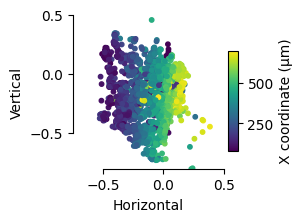

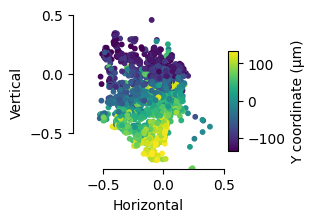

In [23]:
data_key = datakeys[0]
print (f'data_key: {data_key}')
dataset = data_loaders['train'][data_key].dataset
cell_x, cell_y, cell_z = dataset.neurons.cell_motor_coordinates.T
# get readout weights
readout_x, readout_y = factorised_3d_model.readout[data_key].mu.detach().cpu().numpy().squeeze().T

fig, ax = plt.subplots(figsize=(2,2))
im = ax.scatter(readout_x, readout_y, c=cell_x, s=10)
ax.set_xlim(-0.75, 0.5)
ax.set_ylim(-0.8, 0.4)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_yticks([-0.5, 0, 0.5])
ax.set_xlabel('Horizontal')
ax.set_ylabel('Vertical')
sns.despine(trim=True)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.2, 0.05, 0.5])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.2, 0.05, 0.5])
fig.colorbar(im, cax=cax)
cax.set_ylabel('X coordinate (μm)')
# plt.savefig(f"out_result/explicit_readout_no_coordinate_retinotopy_x.svg")

fig, ax = plt.subplots(figsize=(2,2))
im = ax.scatter(readout_x, readout_y, c=cell_y, s=10)
ax.set_xlim(-0.75, 0.5)
ax.set_ylim(-0.8, 0.4)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_yticks([-0.5, 0, 0.5])
ax.set_xlabel('Horizontal')
ax.set_ylabel('Vertical')
sns.despine(trim=True)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.2, 0.05, 0.5])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.2, 0.05, 0.5])
fig.colorbar(im, cax=cax)
cax.set_ylabel('Y coordinate (μm)')
# plt.savefig(f"out_result/explicit_readout_no_coordinate_retinotopy_y.svg")

In [25]:
gaussian_readouts = {}
gaussian_readouts['unit_ids'] = dataset.neurons.unit_ids
gaussian_readouts['readout_x'] = readout_x
gaussian_readouts['readout_y'] = readout_y

# import pickle 

# with open('out/model_seed_111_v05aa_gaussian_readouts_29163-4-4.pkl', 'wb') as ff:
#     pickle.dump(gaussian_readouts, ff)
        
# # with open('saved_dictionary.pkl', 'rb') as f:
# #     loaded_dict = pickle.load(f)

## Confusion matrix for responses or feature weights

In [23]:
datakey = list(data_loaders['train'].keys())[0]
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']
for ii in range(len(feature_latent_flags)):
    tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[ii] + '.pth' 
    factorised_3d_model = make_video_model(
        data_loaders,
        seed,
        core_dict=factorised_3D_core_dict,
        core_type='3D_factorised',
        readout_dict=readout_dict.copy(),
        readout_type='gaussian',               
        use_gru=False,
        gru_dict=None,
        use_shifter=True,
        shifter_dict=shifter_dict,
        shifter_type='MLP',
        feature_latent_flag=feature_latent_flags[ii], # True # False
        feature_latent_dim=2,
        position_encoding_flag=position_encoding_flag,
        position_encoding_k=16,
    )
    factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
    factorised_3d_model.eval()
    # responses_aligns: a  dict of responses_align
    # responses_align: a list of array, each array corresponds to reponses to one condition_hash,
    # array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
    evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
        factorised_3d_model, data_loaders, tier='test', stimulus_type='clip', device=device, 
        datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],],  # [datakeys[0], ]
        pad_responses=True)

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


In [24]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
all_clusterID, all_natural_true = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_clean[
        (all_cluster_clean['animal_id'] == int(animal_id_str)) &
        (all_cluster_clean['session_id'] == int(session_id_str)) &
        (all_cluster_clean['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'clusterID'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    # features_np = features_np[indices_in_unit_ids,:]
    try:
        features_np = np.vstack([np.mean(temp, axis=0) for temp in responses_aligns[datakey]]).transpose()
        features_np = features_np[indices_in_unit_ids,:]
        print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
        all_clusterID.append(clusterID)
        all_natural_true.append(features_np)
    except KeyError:
        print (f"The key '{datakey}' does not exist")
all_clusterID = np.hstack(all_clusterID)
all_natural_true = np.vstack(all_natural_true)
print (f'all_clusterID.shape: {all_clusterID.shape}, all_natural_true.shape: {all_natural_true.shape}')

# Define threshold
threshold = 40
# Count occurrences of each class
class_counts = Counter(all_clusterID)
# Identify small classes
small_classes = {label for label, count in class_counts.items() if count < threshold}
print("Classes to merge:", small_classes)
# Replace small classes with a new label (e.g., "other" = -1)
merged_labels = np.where(np.isin(all_clusterID, list(small_classes)), -1, all_clusterID)
print (f'merged_labels.shape: {merged_labels.shape}')

# Get the sorting indices based on ids
sorted_indices = np.argsort(merged_labels)
# Use the sorting indices to reorder both arrays
merged_labels = merged_labels[sorted_indices]
all_natural_true = all_natural_true[sorted_indices]

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (1663,), features_np.shape: (1663, 1794)
The key 'dynamic28188-18-4-Fluorescence-7b721b-v4a' does not exist
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (568,), features_np.shape: (568, 1794)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (589,), features_np.shape: (589, 1794)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (645,), features_np.shape: (645, 1794)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (220,), features_np.shape: (220, 1794)
The key 'dynamic28188-17-2-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic29163-2-7-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-5-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-3-Fluorescence-7b721b-v4a' does not exist
all_clusterID.shape: (3685,), all_natural_true.shape: (3685, 1794)
Classes to merge: {np.int64(7), np.int64(9), np.int64(11), np

In [25]:
factorised_3d_model.eval()
# responses_aligns: a  dict of responses_align
# responses_align: a list of array, each array corresponds to reponses to one condition_hash,
# array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
    factorised_3d_model, data_loaders, tier='test', stimulus_type="presentmoviearray",
    evaluation_hashes_unique=[
        "fQnZOaH1tdWxRyb3ipGZ", # chirp
        "0N5anjqjPcKoH66W9mzf", # moving_bar
    ], 
    device=device,
    datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],],  # [datakeys[0], ]
    pad_responses=True,
)

In [26]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
temphashindex=0 # chirp
all_clusterID, all_chirp_true = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_clean[
        (all_cluster_clean['animal_id'] == int(animal_id_str)) &
        (all_cluster_clean['session_id'] == int(session_id_str)) &
        (all_cluster_clean['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'clusterID'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    # features_np = features_np[indices_in_unit_ids,:]
    try:
        features_np = np.mean(responses_aligns[datakey][temphashindex], axis=0).transpose()
        features_np = features_np[indices_in_unit_ids,:]
        print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
        all_clusterID.append(clusterID)
        all_chirp_true.append(features_np)
    except KeyError:
        print (f"The key '{datakey}' does not exist")
all_clusterID = np.hstack(all_clusterID)
all_chirp_true = np.vstack(all_chirp_true)
print (f'all_clusterID.shape: {all_clusterID.shape}, all_chirp_true.shape: {all_chirp_true.shape}')

# Define threshold
threshold = 40
# Count occurrences of each class
class_counts = Counter(all_clusterID)
# Identify small classes
small_classes = {label for label, count in class_counts.items() if count < threshold}
print("Classes to merge:", small_classes)
# Replace small classes with a new label (e.g., "other" = -1)
merged_labels = np.where(np.isin(all_clusterID, list(small_classes)), -1, all_clusterID)
print (f'merged_labels.shape: {merged_labels.shape}')

# Get the sorting indices based on ids
sorted_indices = np.argsort(merged_labels)
# Use the sorting indices to reorder both arrays
merged_labels = merged_labels[sorted_indices]
all_chirp_true = all_chirp_true[sorted_indices]

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (1663,), features_np.shape: (1663, 958)
The key 'dynamic28188-18-4-Fluorescence-7b721b-v4a' does not exist
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (568,), features_np.shape: (568, 958)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (589,), features_np.shape: (589, 958)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (645,), features_np.shape: (645, 958)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (220,), features_np.shape: (220, 958)
The key 'dynamic28188-17-2-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic29163-2-7-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-5-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-3-Fluorescence-7b721b-v4a' does not exist
all_clusterID.shape: (3685,), all_chirp_true.shape: (3685, 958)
Classes to merge: {np.int64(7), np.int64(9), np.int64(11), np.int64(1

In [27]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
all_clusterID, all_features_np = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_clean[
        (all_cluster_clean['animal_id'] == int(animal_id_str)) &
        (all_cluster_clean['session_id'] == int(session_id_str)) &
        (all_cluster_clean['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'clusterID'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    # features_np = features_np[indices_in_unit_ids,:]
    try:
        features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
        features_np = features_np[indices_in_unit_ids,:]
        print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
        all_clusterID.append(clusterID)
        all_features_np.append(features_np)
    except KeyError:
        print (f"The key '{datakey}' does not exist")
all_clusterID = np.hstack(all_clusterID)
all_features_np = np.vstack(all_features_np)
print (f'all_clusterID.shape: {all_clusterID.shape}, all_features_np.shape: {all_features_np.shape}')

# Define threshold
threshold = 40
# Count occurrences of each class
class_counts = Counter(all_clusterID)
# Identify small classes
small_classes = {label for label, count in class_counts.items() if count < threshold}
print("Classes to merge:", small_classes)
# Replace small classes with a new label (e.g., "other" = -1)
merged_labels = np.where(np.isin(all_clusterID, list(small_classes)), -1, all_clusterID)
print (f'merged_labels.shape: {merged_labels.shape}')

# Get the sorting indices based on ids
sorted_indices = np.argsort(merged_labels)
# Use the sorting indices to reorder both arrays
merged_labels = merged_labels[sorted_indices]
all_features_np = all_features_np[sorted_indices]

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (1663,), features_np.shape: (1663, 64)
datakey: dynamic28188-18-4-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (568,), features_np.shape: (568, 64)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (589,), features_np.shape: (589, 64)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (645,), features_np.shape: (645, 64)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (220,), features_np.shape: (220, 64)
datakey: dynamic28188-17-2-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic29163-2-7-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-5-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-3-Fluorescence-7b721b-v4a, clusterID.sha

In [28]:
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute Pearson Correlation Distance for Artificial and Natural Responses
def compute_correlation_matrix(data):
    """Compute pairwise Pearson correlation matrix and convert to distance."""
    corr = np.corrcoef(data)  # Correlation matrix
    distance = 1 - corr       # Convert correlation to distance
    return distance

# Compute Cosine Distance for Feature Weights
def compute_cosine_distance(features):
    """Compute pairwise cosine distance matrix."""
    cosine_sim = cosine_similarity(features)
    distance = 1 - cosine_sim  # Convert similarity to distance
    # Clip small negative values caused by numerical errors
    distance = np.clip(distance, a_min=0, a_max=None)
    return distance

# Compute Distance Matrices
distance_chirp_true = compute_correlation_matrix(all_chirp_true)
distance_natural_true = compute_correlation_matrix(all_natural_true)
distance_features_np = compute_cosine_distance(all_features_np)

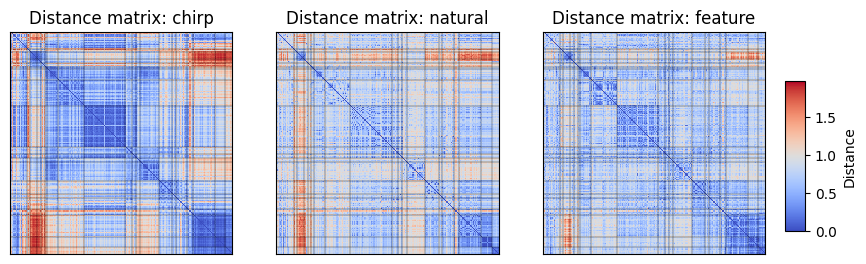

In [30]:
vmin = np.min([distance_chirp_true, distance_natural_true, distance_features_np])
vmax = np.max([distance_chirp_true, distance_natural_true, distance_features_np])
# Find the indices where cluster_ID changes
change_indices = np.where(np.diff(merged_labels) != 0)[0] + 1  # Add 1 to shift to the next position
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,3))
im=ax[0].matshow(distance_chirp_true, vmin=vmin, vmax=vmax, cmap='coolwarm') # cmap='coolwarm'
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Distance matrix: chirp")
ax[1].matshow(distance_natural_true, vmin=vmin, vmax=vmax, cmap='coolwarm')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Distance matrix: natural")
ax[2].matshow(distance_features_np, vmin=vmin, vmax=vmax, cmap='coolwarm')
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title("Distance matrix: feature")
# Add horizontal and vertical lines at cluster boundaries
for idx in change_indices:
    for ii in range(3):
        ax[ii].axhline(y=idx - 0.5, color='black', linewidth=0.25)  # Horizontal line
        ax[ii].axvline(x=idx - 0.5, color='black', linewidth=0.25)  # Vertical line

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.2, 0.02, 0.5])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.2, 0.05, 0.5])
fig.colorbar(im, cax=cax)
cax.set_ylabel('Distance')
# plt.savefig(f"out_result/explicit_readout_feature_weight_and_chirp_natural_movies_responses_distance_matrix.svg")

In [31]:
'''
High rank correlation between the feature-based matrix and the response-based matrices suggests that the learned model captures relationships similar to responses.
If the feature-based matrix decorrelates from both response-based matrices, it might indicate the model captures a new structure or abstraction not present in the responses.
'''

from scipy.stats import spearmanr
def compare_matrices(matrix1, matrix2):
    """Compare two similarity matrices using Spearman rank correlation."""
    triu_idx = np.triu_indices_from(matrix1, k=1)
    flattened1 = matrix1[triu_idx]
    flattened2 = matrix2[triu_idx]
    correlation, _ = spearmanr(flattened1, flattened2)
    return correlation, flattened1, flattened2

# Compare matrices
corr_chirp_natural, _, _ = compare_matrices(distance_chirp_true, distance_natural_true)
corr_chirp_features, _, _ = compare_matrices(distance_chirp_true, distance_features_np)
corr_natural_features, _, _ = compare_matrices(distance_natural_true, distance_features_np)

print(f"Spearman Correlation: Chirp vs Natural = {corr_chirp_natural:.3f}")
print(f"Spearman Correlation: Chirp vs Features = {corr_chirp_features:.3f}")
print(f"Spearman Correlation: Natural vs Features = {corr_natural_features:.3f}")

# fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(6, 2))
# ax[0].scatter(flatten_chirp, flatten_natural, s=0.01, color='gray')
# ax[0].set_xlabel('Dis. mat.: chirp')
# ax[0].set_ylabel('Dis. mat.: natural')
# ax[0].set_title(f'Spearman: {corr_chirp_natural:.3f}')
# adjust_spines(ax[0], ['left', 'bottom'])
# ax[1].scatter(flatten_chirp, flatten_features, s=0.01, color='gray')
# ax[1].set_xlabel('Dis. mat.: chirp')
# ax[1].set_ylabel('Dis. mat.: feature')
# ax[1].set_title(f'Spearman: {corr_chirp_features:.3f}')
# adjust_spines(ax[1], ['left', 'bottom'])
# ax[2].scatter(flatten_natural, flatten_features, s=0.01, color='gray')
# ax[2].set_xlabel('Dis. mat.: natural')
# ax[2].set_ylabel('Dis. mat.: feature')
# ax[2].set_title(f'Spearman: {corr_natural_features:.3f}')
# adjust_spines(ax[2], ['left', 'bottom'])
# # plt.savefig(f"out_result/explicit_readout_feature_weight_predict_on_off_idx.svg")

Spearman Correlation: Chirp vs Natural = 0.581
Spearman Correlation: Chirp vs Features = 0.555
Spearman Correlation: Natural vs Features = 0.626


In [32]:
'''
To identify which types (among the 28 types) show the largest divergence between the two distance matrices (e.g., "chirp" responses and "feature weights"), 
we can compute per-cluster divergence
'''
# Step 1: Find unique clusters (types)
unique_types = np.unique(merged_labels)
# Step 2: Initialize a dictionary to store divergence results
divergence_scores = {}
# Step 3: Loop over each cluster type and compute divergence
for cluster in unique_types:
    # Get indices of neurons belonging to the current cluster
    cluster_indices = np.where(merged_labels == cluster)[0]
    cluster_size = len(cluster_indices)
    # Subset the distance matrices for this cluster
    chirp_submatrix = distance_chirp_true[np.ix_(cluster_indices, cluster_indices)]
    feature_submatrix = distance_features_np[np.ix_(cluster_indices, cluster_indices)]
    # Flatten the matrices and compute Spearman correlation
    chirp_flat = chirp_submatrix[np.triu_indices_from(chirp_submatrix, k=1)]  # Upper triangular values
    feature_flat = feature_submatrix[np.triu_indices_from(feature_submatrix, k=1)]
    if len(chirp_flat) > 1:  # Ensure there are enough points to compute correlation
        correlation, _ = spearmanr(chirp_flat, feature_flat)
        # Compute the Frobenius norm of the difference as another measure (average Frobenius norm)
        frob_norm = np.linalg.norm(chirp_submatrix - feature_submatrix)/( cluster_size * (cluster_size - 1) / 2 )
    else:
        correlation = np.nan  # Not enough data for this cluster
        frob_norm = np.nan
    # Store results
    divergence_scores[cluster] = {'Spearman Correlation': correlation, 'Frobenius Norm': frob_norm}

# Step 4: Sort clusters by divergence (Frobenius norm or Spearman correlation)
sorted_by_frob = sorted(divergence_scores.items(), key=lambda x: x[1]['Frobenius Norm'], reverse=True)
sorted_by_corr = sorted(divergence_scores.items(), key=lambda x: x[1]['Spearman Correlation'])

# Print results
# print("Clusters Sorted by Frobenius Norm (Largest Divergence):")
# for cluster, scores in sorted_by_frob:
#     print(f"Cluster {cluster}: Frobenius Norm = {scores['Frobenius Norm']:.3f}, Spearman Correlation = {scores['Spearman Correlation']:.3f}")

print (f'unique_types: {unique_types}')
print("\nClusters Sorted by Spearman Correlation (Lowest to Highest):")
for cluster, scores in sorted_by_corr:
    print(f"Cluster {cluster}: Spearman Correlation = {scores['Spearman Correlation']:.3f}, Frobenius Norm = {scores['Frobenius Norm']:.3f}")

unique_types: [-1  0  1  2  3 10 13 17 21 24 25 28 29 31 32 33 35 38 40 46]

Clusters Sorted by Spearman Correlation (Lowest to Highest):
Cluster 29: Spearman Correlation = 0.171, Frobenius Norm = 0.002
Cluster 46: Spearman Correlation = 0.286, Frobenius Norm = 0.002
Cluster 28: Spearman Correlation = 0.381, Frobenius Norm = 0.008
Cluster 25: Spearman Correlation = 0.390, Frobenius Norm = 0.008
Cluster 24: Spearman Correlation = 0.393, Frobenius Norm = 0.005
Cluster 3: Spearman Correlation = 0.398, Frobenius Norm = 0.008
Cluster -1: Spearman Correlation = 0.413, Frobenius Norm = 0.003
Cluster 32: Spearman Correlation = 0.459, Frobenius Norm = 0.008
Cluster 33: Spearman Correlation = 0.497, Frobenius Norm = 0.002
Cluster 35: Spearman Correlation = 0.511, Frobenius Norm = 0.007
Cluster 17: Spearman Correlation = 0.533, Frobenius Norm = 0.001
Cluster 31: Spearman Correlation = 0.565, Frobenius Norm = 0.002
Cluster 1: Spearman Correlation = 0.566, Frobenius Norm = 0.003
Cluster 0: Spearman

In [33]:
'''
A higher Silhouette Score or lower Davies-Bouldin Index for the feature-based matrix suggests better clustering quality.
If clustering on the feature weights achieves better results than on artificial or natural responses, it supports your hypothesis.
'''

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

def clustering_analysis(distance_matrix, n_clusters):
    """Perform clustering and compute evaluation metrics."""
    model = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
    labels = model.fit_predict(distance_matrix)
    sil_score = silhouette_score(distance_matrix, labels, metric='precomputed')
    db_index = davies_bouldin_score(distance_matrix, labels)
    return labels, sil_score, db_index

# Example: Perform clustering for all matrices
n_clusters = 28  # You can experiment with the number of clusters
labels_chirp, sil_chirp, db_chirp = clustering_analysis(distance_chirp_true, n_clusters)
labels_natural, sil_nat, db_nat = clustering_analysis(distance_natural_true, n_clusters)
labels_features, sil_feat, db_feat = clustering_analysis(distance_features_np, n_clusters)

# Compare the results
print(f"Chirp Stimuli     - Silhouette: {sil_chirp:.3f}, Davies-Bouldin: {db_chirp:.3f}")
print(f"Natural Movies    - Silhouette: {sil_nat:.3f}, Davies-Bouldin: {db_nat:.3f}")
print(f"Feature Weights   - Silhouette: {sil_feat:.3f}, Davies-Bouldin: {db_feat:.3f}")


Chirp Stimuli     - Silhouette: 0.228, Davies-Bouldin: 1.220
Natural Movies    - Silhouette: 0.187, Davies-Bouldin: 1.433
Feature Weights   - Silhouette: 0.260, Davies-Bouldin: 1.644


## clusterID_clean - explicit readout

In [34]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


<All keys matched successfully>

In [35]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
all_clusterID, all_features_np = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_clean[
        (all_cluster_clean['animal_id'] == int(animal_id_str)) &
        (all_cluster_clean['session_id'] == int(session_id_str)) &
        (all_cluster_clean['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'clusterID'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    features_np = features_np[indices_in_unit_ids,:]
    print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
    all_clusterID.append(clusterID)
    all_features_np.append(features_np)
all_clusterID = np.hstack(all_clusterID)
all_features_np = np.vstack(all_features_np)
print (f'all_clusterID.shape: {all_clusterID.shape}, all_features_np.shape: {all_features_np.shape}')

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (1663,), features_np.shape: (1663, 64)
datakey: dynamic28188-18-4-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (568,), features_np.shape: (568, 64)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (589,), features_np.shape: (589, 64)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (645,), features_np.shape: (645, 64)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (220,), features_np.shape: (220, 64)
datakey: dynamic28188-17-2-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic29163-2-7-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-5-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-3-Fluorescence-7b721b-v4a, clusterID.sha

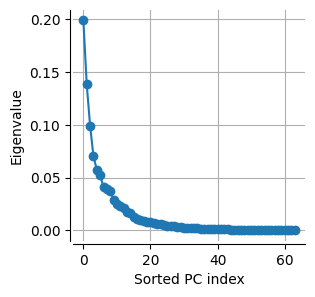

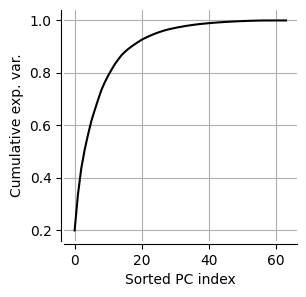

In [41]:
# the eigenspectrum of the covariance matrix for all_features_np
# Step 1: Ensure the data is centered (mean-subtracted)
data_centered = all_features_np - np.mean(all_features_np, axis=0)
# Step 2: Use PCA to compute the eigenspectrum
pca = PCA()
pca.fit(data_centered)
# Step 3: Get the eigenvalues (explained variance)
eigenspectrum = pca.explained_variance_ratio_
# Step 4: Optional - Sort the eigenspectrum in descending order (if needed)
eigenspectrum_sorted = np.sort(eigenspectrum)[::-1]

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(eigenspectrum_sorted, marker='o', linestyle='-')
ax.set_xlabel("Sorted PC index")
ax.set_ylabel("Eigenvalue")
adjust_spines(ax, ['left', 'bottom'])
plt.grid(True)

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(np.cumsum(eigenspectrum_sorted), color='k', linestyle='-')
ax.set_xlabel("Sorted PC index")
ax.set_ylabel("Cumulative exp. var.")
adjust_spines(ax, ['left', 'bottom'])
plt.grid(True)
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA.svg")

In [42]:
len(np.unique(all_clusterID)), np.unique(all_clusterID), Counter(all_clusterID)

(39,
 array([ 0,  1,  2,  3,  7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21,
        22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 38, 40, 42, 43,
        45, 46, 47, 48, 49]),
 Counter({np.int64(21): 687,
          np.int64(17): 422,
          np.int64(38): 359,
          np.int64(29): 310,
          np.int64(31): 225,
          np.int64(33): 195,
          np.int64(13): 182,
          np.int64(40): 181,
          np.int64(1): 121,
          np.int64(24): 113,
          np.int64(46): 109,
          np.int64(35): 91,
          np.int64(28): 69,
          np.int64(25): 68,
          np.int64(3): 63,
          np.int64(2): 60,
          np.int64(32): 55,
          np.int64(0): 48,
          np.int64(10): 40,
          np.int64(49): 38,
          np.int64(43): 37,
          np.int64(42): 35,
          np.int64(16): 32,
          np.int64(12): 31,
          np.int64(48): 28,
          np.int64(47): 18,
          np.int64(45): 18,
          np.int64(34): 18,
          np.int64(18)

(array([ 48., 121.,  60.,  63.,   0.,   0.,   0.,   1.,   0.,   4.,  40.,
          2.,  31., 182.,   1.,   1.,  32., 422.,  11.,   0.,   6., 687.,
          2.,   1., 113.,  68.,   0.,   1.,  69., 310.,   2., 225.,  55.,
        195.,  18.,  91.,   0.,   0., 359.,   0., 181.,   0.,  35.,  37.,
          0.,  18., 109.,  18.,  28.,  38.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 <BarContainer object of 50 artists>)

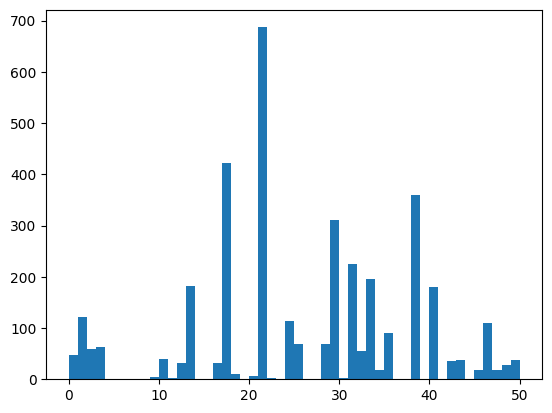

In [43]:
plt.hist(all_clusterID, bins=50, range=(0,50))

Classes to merge: {np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(23), np.int64(27), np.int64(30), np.int64(34), np.int64(42), np.int64(43), np.int64(45), np.int64(47), np.int64(48), np.int64(49)}
Original unique classes: [ 0  1  2  3  7  9 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 27 28 29
 30 31 32 33 34 35 38 40 42 43 45 46 47 48 49]
Merged unique classes: [-1  0  1  2  3 10 13 17 21 24 25 28 29 31 32 33 35 38 40 46]


(array([287.,  48., 121.,  60.,  63.,   0.,   0.,   0.,   0.,   0.,   0.,
         40.,   0.,   0., 182.,   0.,   0.,   0., 422.,   0.,   0.,   0.,
        687.,   0.,   0., 113.,  68.,   0.,   0.,  69., 310.,   0., 225.,
         55., 195.,   0.,  91.,   0.,   0., 359.,   0., 181.,   0.,   0.,
          0.,   0.,   0., 109.,   0.,   0.,   0.]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
        12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.,
        25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37.,
        38., 39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 <BarContainer object of 51 artists>)

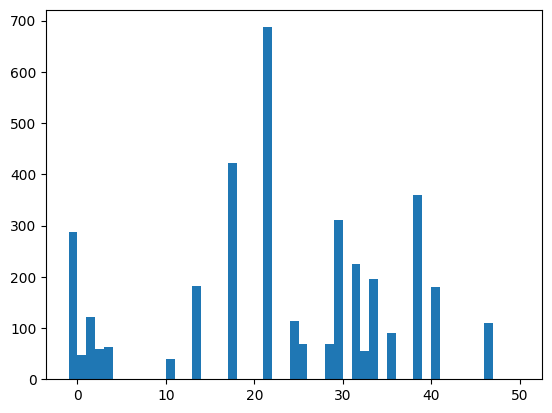

In [44]:
# Define threshold
threshold = 40
# Count occurrences of each class
class_counts = Counter(all_clusterID)
# Identify small classes
small_classes = {label for label, count in class_counts.items() if count < threshold}
print("Classes to merge:", small_classes)
# Replace small classes with a new label (e.g., "other" = -1)
merged_labels = np.where(np.isin(all_clusterID, list(small_classes)), -1, all_clusterID)
print("Original unique classes:", np.unique(all_clusterID))
print("Merged unique classes:", np.unique(merged_labels))
plt.hist(merged_labels, bins=51, range=(-1,50))

In [45]:
# Example dataset (replace with your own dataset)
# X, y = make_classification(n_samples=7000, n_features=60, n_classes=40, random_state=42)
XX, yy = np.copy(all_features_np), np.copy(merged_labels)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('logreg', LogisticRegression(class_weight='balanced',solver='lbfgs', max_iter=2000)), # imbalanced data
    # ('logreg', LogisticRegression(class_weight='balanced',solver='lbfgs', max_iter=1000)), # imbalanced data
    # ('logreg', LogisticRegression(class_weight='balanced',solver='saga', max_iter=1000)), # imbalanced data
])
# Define parameter grid for inner loop (hyperparameter tuning)
param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}
# Outer loop (10-fold cross-validation); for imbalanced data
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# To store results
nested_scores = []
confusion_matrices = []
# Perform nested cross-validation
for train_idx, test_idx in outer_cv.split(XX, yy): #  StratifiedKFold.split() requires two arguments: the feature data (X) and the labels (y).
    # Split data into training and test sets for the outer loop
    X_train, X_test = XX[train_idx], XX[test_idx]
    y_train, y_test = yy[train_idx], yy[test_idx]
    # Inner loop: Perform hyperparameter tuning using GridSearchCV; for imbalanced data
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV for tuning
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',  # imbalanced data
        verbose=1,  # 0
    )
    # Fit GridSearchCV on the training data from the outer loop
    grid_search.fit(X_train, y_train)
    # Best model from the inner loop
    best_model = grid_search.best_estimator_  # grid_search.best_params_
    
    # Evaluate the best model on the outer loop test set
    y_pred = best_model.predict(X_test)
    outer_score = balanced_accuracy_score(y_test, y_pred)
    nested_scores.append(outer_score)
    # Compute confusion matrix for the fold
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(yy))
    confusion_matrices.append(cm)
    # Evaluate performance
    print("Classification Report:")
    print(classification_report(y_test, y_pred))  # Balanced Accuracy=Macro Avg (Recall)

# Report nested cross-validation results
print("Nested CV Accuracy Scores:", nested_scores)
print("Mean Accuracy:", np.mean(nested_scores))
print("Standard Deviation:", np.std(nested_scores))
# Aggregate confusion matrix
overall_cm = sum(confusion_matrices)
print("Overall Confusion Matrix (summed across folds):")
print(overall_cm)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Classification Report:
              precision    recall  f1-score   support

          -1       0.47      0.28      0.35        29
           0       0.50      0.80      0.62         5
           1       0.91      0.83      0.87        12
           2       0.57      0.67      0.62         6
           3       0.44      0.67      0.53         6
          10       0.57      1.00      0.73         4
          13       0.77      0.94      0.85        18
          17       0.95      0.84      0.89        43
          21       0.91      0.77      0.83        69
          24       0.64      0.82      0.72        11
          25       0.54      1.00      0.70         7
          28       0.50      0.57      0.53         7
          29       0.90      0.87      0.89        31
          31       1.00      0.82      0.90        22
          32       0.33      0.60      0.43         5
          33       0.58      0.70      0.64        2

Text(0, 0.5, 'Normalized probability')

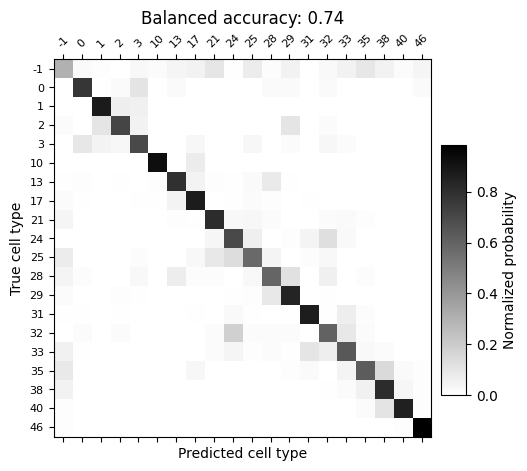

In [46]:
templabels = [str(ii) for ii in np.unique(merged_labels).tolist()]
fig, ax = plt.subplots(figsize=(5,5))
im = ax.matshow(overall_cm/np.sum(overall_cm, axis=1, keepdims=True), cmap='gray_r')
ax.set_xticks(np.arange(overall_cm.shape[0]).tolist())
ax.set_xticklabels(templabels, rotation=45, fontsize=8)
ax.set_yticks(np.arange(overall_cm.shape[0]).tolist())
ax.set_yticklabels(templabels, fontsize=8)
ax.set_xlabel('Predicted cell type')
ax.set_ylabel('True cell type')
ax.set_title(f'Balanced accuracy: {np.mean(nested_scores):.2f}')
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.2, 0.05, 0.5])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.2, 0.05, 0.5])
fig.colorbar(im, cax=cax)
cax.set_ylabel('Normalized probability')
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_clusterID_clean.svg")

In [47]:
best_model

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1


In [48]:
# for exemplary predicted cluster, plot the recorded chirp responses
XX, yy = np.copy(all_features_np), np.copy(merged_labels)
yy_pred = best_model.predict(XX)
# np.unique(yy_pred)
temptype = 0
print (f'len(np.where(yy_pred==2)[0]): {len(np.where(yy_pred==temptype)[0])}')
print ('\n')

# get aligned recorded responses
factorised_3d_model.eval()
# responses_aligns: a  dict of responses_align
# responses_align: a list of array, each array corresponds to reponses to one condition_hash,
# array shape (num_of_repeats_for_that_hash, num_of_frames_for_that_trial, num_of_neurons)
evaluation_hashes_unique, responses_aligns, predictions_aligns = model_predictions_align(
    factorised_3d_model, 
    data_loaders, tier='test', stimulus_type="presentmoviearray",
    evaluation_hashes_unique=[
        "fQnZOaH1tdWxRyb3ipGZ", # chirp
        "0N5anjqjPcKoH66W9mzf", # moving_bar
    ], 
    device=device,
    datakeys=[datakeys[0], datakeys[2], datakeys[3], datakeys[4], datakeys[5],],  # [datakeys[0], ]
    pad_responses=True,
)
print ('\n')

# select the boutons from the cluster info table, and get their recorded responses
# Note that 28188-18-4 does not have responses to chirp and moving_bar
temphashindex=0 # chirp
all_clusterID, all_chirp_true = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_clean[
        (all_cluster_clean['animal_id'] == int(animal_id_str)) &
        (all_cluster_clean['session_id'] == int(session_id_str)) &
        (all_cluster_clean['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'clusterID'].values
    #
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    # features_np = features_np[indices_in_unit_ids,:]
    try:
        features_np = np.mean(responses_aligns[datakey][temphashindex], axis=0).transpose()
        features_np = features_np[indices_in_unit_ids,:]
        print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
        all_clusterID.append(clusterID)
        all_chirp_true.append(features_np)
    except KeyError:
        print (f"The key '{datakey}' does not exist")
all_clusterID = np.hstack(all_clusterID)
all_chirp_true = np.vstack(all_chirp_true)
print (f'all_clusterID.shape: {all_clusterID.shape}, all_chirp_true.shape: {all_chirp_true.shape}')

len(np.where(yy_pred==2)[0]): 64




datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (1663,), features_np.shape: (1663, 958)
The key 'dynamic28188-18-4-Fluorescence-7b721b-v4a' does not exist
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (568,), features_np.shape: (568, 958)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (589,), features_np.shape: (589, 958)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (645,), features_np.shape: (645, 958)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (220,), features_np.shape: (220, 958)
The key 'dynamic28188-17-2-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic29163-2-7-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-5-Fluorescence-7b721b-v4a' does not exist
The key 'dynamic28188-16-3-Fluorescence-7b721b-v4a' does not exist
all_clusterID.shape: (3685,), all_chirp_true.shape: (3685, 958)


(50, 958)
(129, 958)


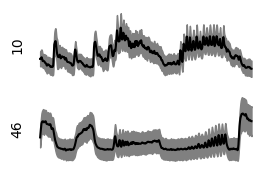

In [49]:
temptypes = [10, 46]
nrows = len(temptypes)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(3,2))
for ii in range(nrows):
    temps = all_chirp_true[np.where(yy_pred==temptypes[ii])[0], :]
    print (temps.shape)
    temps_mean = np.mean(temps, axis=0)
    temps_std = np.std(temps, axis=0, ddof=1)
    axes[ii].fill_between(np.arange(len(temps_mean)), temps_mean - temps_std, temps_mean + temps_std, color='gray')
    axes[ii].plot(np.arange(len(temps_mean)), temps_mean, color='k')
    axes[ii].spines['left'].set_visible(False)
    axes[ii].spines['bottom'].set_visible(False)
    axes[ii].spines['right'].set_visible(False)
    axes[ii].spines['top'].set_visible(False)
    axes[ii].set_xticks([])
    axes[ii].set_yticks([])
    axes[ii].set_ylabel(f'{temptypes[ii]}')
# plt.savefig(f"out_result/predict_clusterID_clean_example_true_trace.svg")

coefficients.shape: (20, 64)


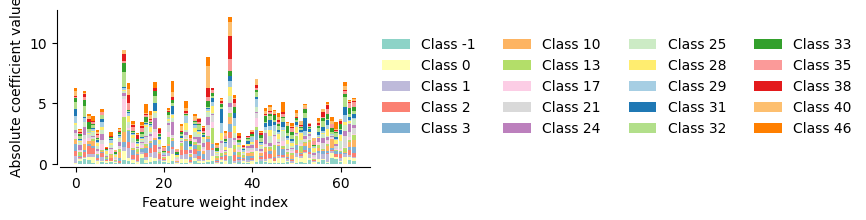

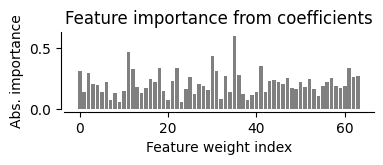

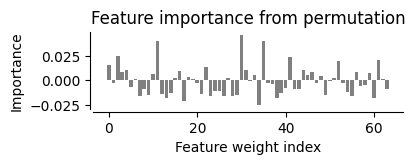

In [52]:
# Access coefficients (shape: [n_classes, n_features])
coefficients = np.abs(best_model.named_steps['logreg'].coef_)
print (f'coefficients.shape: {coefficients.shape}')

# Combine multiple Matplotlib colormaps
set3_colors = plt.get_cmap('Set3').colors
paired_colors = plt.get_cmap('Paired').colors
accent_colors = plt.get_cmap('Accent').colors
# Concatenate colors and limit to 28
combined_colors = list(set3_colors) + list(paired_colors) + list(accent_colors)
custom_cmap = ListedColormap(combined_colors[:28])
#
# num_colors = 28
# colors = [plt.get_cmap('viridis')(i / (num_colors - 1)) for i in range(num_colors)]

templabels = [str(ii) for ii in np.unique(merged_labels).tolist()]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (4,2))
# Initialize the bottom of the stack
bottom = np.zeros(coefficients.shape[1])  # One value per feature index
# Plot feature importance for one class
for ii in range(coefficients.shape[0]):  # Iterate through classes
# for i in [1, 27]:  # Iterate through classes
    ax.bar(range(coefficients.shape[1]), coefficients[ii], bottom=bottom, label=f'Class {templabels[ii]}', color=custom_cmap(ii))
    # ax.bar(range(coefficients.shape[1]), coefficients[ii], bottom=bottom, label=f'Class {templabels[ii]}', color=colors[ii])
    # Update the bottom for the next class
    bottom += coefficients[ii]
ax.set_xlabel('Feature weight index')
ax.set_ylabel('Absolute coefficient value')
# ax.set_title('Feature Importance by Class')
# ax.legend(loc='best')
adjust_spines(ax, ['left', 'bottom'])
handles, labels = ax.get_legend_handles_labels()
# lgd = ax.legend(handles, labels, loc='center left',frameon=False, bbox_to_anchor=(1, 0.5))
lgd = ax.legend(
    handles,
    labels,
    loc='center left',
    frameon=False,
    bbox_to_anchor=(1, 0.5),
    ncol=4  # Set number of columns in the legend
)
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_clusterID_abs_coefficient.svg")

# Get the absolute importance for a single-class (binary) model or average for multiclass
feature_importance = np.mean(np.abs(best_model.named_steps['logreg'].coef_), axis=0)
#
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (4,1))
ax.bar(range(len(feature_importance)), feature_importance, color='gray')
ax.set_xlabel('Feature weight index')
ax.set_ylabel('Abs. importance')
ax.set_title('Feature importance from coefficients')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_clusterID_importance_coefficient.svg")

# Feature Importance from Permutation
result = permutation_importance(best_model, X_test, y_test, scoring='balanced_accuracy') # imbalanced data
#
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (4,1))
ax.bar(range(X_test.shape[1]), result.importances_mean, color='gray')
ax.set_xlabel('Feature weight index')
ax.set_ylabel('Importance')
ax.set_title('Feature importance from permutation')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_clusterID_importance_permutation.svg")

reduced_data.shape: (3685, 2)


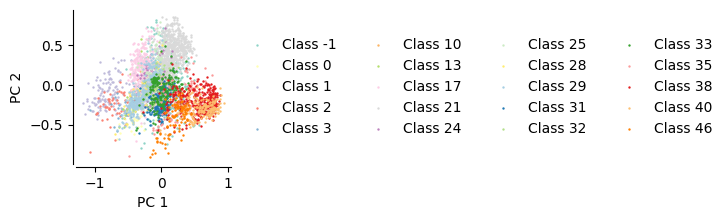

In [56]:
# Apply PCA or TSNE
# reduced_data = PCA(n_components=2).fit_transform(all_features_np)  # Replace with TSNE(n_components=2) for t-SNE
# # reduced_data = TSNE(n_components=2).fit_transform(all_features_np) 
#
def pca_on_data_split(responses_train, responses_val, n_components=2):
    """
    PCA
    Args:
        responses_train: 2D numpy array, shape: (num_of_samples, num_of_neurons), 
                         the pca would be applied on the second axis (features),
                         this is for training the PCA             
    Return:
    """
    # print (f'responses_train.shape: {responses_train.shape}') # shape: S X N
    responses_train_mean = np.mean(responses_train, axis=0, keepdims=True)
    responses_train_centered = responses_train - responses_train_mean
    pca = PCA(n_components=n_components)
    pca.fit(responses_train_centered)
    #
    # print (f'responses_val.shape: {responses_val.shape}') # shape: S X N
    responses_val_centered = responses_val - responses_train_mean
    responses_val_pca = pca.transform(responses_val_centered)
    # print (f'responses_val_pca.shape: {responses_val_pca.shape}') # shape: S X n_components
    responses_val_recon = pca.inverse_transform(responses_val_pca)
    responses_val_recon += responses_train_mean
    # print (f'responses_val_recon.shape: {responses_val_recon.shape}') # shape: S X N
    #
    # corrs = -2.0 * np.ones((responses_val.shape[1],))
    # for ii in range(len(corrs)):
    #     corrs[ii], _ = pearsonr(responses_val[:,ii], responses_val_recon[:,ii])
    # # print (f'np.mean(corrs): {np.mean(corrs)}')
    # corr = np.mean(corrs)
    return responses_val_pca, responses_val_recon
reduced_data, _ = pca_on_data_split(all_features_np, all_features_np, n_components=2)
print (f'reduced_data.shape: {reduced_data.shape}')

# Combine multiple Matplotlib colormaps
set3_colors = plt.get_cmap('Set3').colors
paired_colors = plt.get_cmap('Paired').colors
accent_colors = plt.get_cmap('Accent').colors
# Concatenate colors and limit to 28
combined_colors = list(set3_colors) + list(paired_colors) + list(accent_colors)
custom_cmap = ListedColormap(combined_colors[:28])
#
# num_colors = 28
# colors = [plt.get_cmap('viridis')(i / (num_colors - 1)) for i in range(num_colors)]

# Plot the reduced data
fig, ax = plt.subplots(figsize=(2, 2))
for ii,class_id in enumerate(np.unique(merged_labels).tolist()):
    ax.scatter(reduced_data[yy == class_id, 0], reduced_data[yy == class_id, 1], s=0.5, label=f'Class {class_id}', color=custom_cmap(ii))
    # ax.scatter(reduced_data[yy == class_id, 0], reduced_data[yy == class_id, 1], s=0.5, label=f'Class {class_id}', color=colors[ii])
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
# ax.title('Class Separability')
adjust_spines(ax, ['left', 'bottom'])

handles, labels = ax.get_legend_handles_labels()
# lgd = ax.legend(handles, labels, loc='center left',frameon=False, bbox_to_anchor=(1, 0.5))
lgd = ax.legend(
    handles,
    labels,
    loc='center left',
    frameon=False,
    bbox_to_anchor=(1, 0.5),
    ncol=4  # Set number of columns in the legend
)

## depth - explicit readout

In [23]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


<All keys matched successfully>

In [24]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
all_clusterID, all_features_np = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_info[
        (all_cluster_info['animal_id'] == int(animal_id_str)) &
        (all_cluster_info['session_id'] == int(session_id_str)) &
        (all_cluster_info['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'depth'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    features_np = features_np[indices_in_unit_ids,:]
    print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
    all_clusterID.append(clusterID)
    all_features_np.append(features_np)
all_depth = np.hstack(all_clusterID)
all_features_np = np.vstack(all_features_np)
print (f'all_depth.shape: {all_depth.shape}, all_features_np.shape: {all_features_np.shape}')

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (3033,), features_np.shape: (3033, 64)
datakey: dynamic28188-18-4-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (1271,), features_np.shape: (1271, 64)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (1014,), features_np.shape: (1014, 64)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (1051,), features_np.shape: (1051, 64)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (636,), features_np.shape: (636, 64)
datakey: dynamic28188-17-2-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic29163-2-7-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-5-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-3-Fluorescence-7b721b-v4a, cluster

In [25]:
len(np.unique(all_depth)), np.unique(all_depth), Counter(all_depth)

(9,
 array([ 20.,  70., 110., 120., 140., 170., 200., 220., 230.]),
 Counter({np.float64(70.0): 2128,
          np.float64(120.0): 1971,
          np.float64(170.0): 1298,
          np.float64(20.0): 885,
          np.float64(220.0): 310,
          np.float64(140.0): 166,
          np.float64(200.0): 132,
          np.float64(230.0): 58,
          np.float64(110.0): 57}))

In [39]:
# # Define threshold
# threshold = 100
# # Count occurrences of each class
# class_counts = Counter(all_depth)
# # Identify small classes
# small_classes = {label for label, count in class_counts.items() if count < threshold}
# print("Classes to merge:", small_classes)
# # Replace small classes with a new label (e.g., "other" = -1)
# merged_labels = np.where(np.isin(all_depth, list(small_classes)), -1, all_depth)
# print("Original unique classes:", np.unique(all_depth))
# print("Merged unique classes:", np.unique(merged_labels))

# merged_labels = np.copy(all_depth)
# Counter(merged_labels)

# bin the depth
def bin_depth(depth, bin_size, min_val=None, max_val=None):
    """
    Bin a 1D array using a specified bin size.
    
    Parameters
    ----------
    depth : np.ndarray
        1D array of values to bin.
    bin_size : float
        Width of each bin.
    min_val : float, optional
        Minimum value for binning (default: depth.min()).
    max_val : float, optional
        Maximum value for binning (default: depth.max()).
    
    Returns
    -------
    bin_indices : np.ndarray
        Bin index for each element in depth.
    bin_edges : np.ndarray
        Edges of the bins.
    bin_centers : np.ndarray
        Centers of the bins.
    """
    
    if min_val is None:
        min_val = np.min(depth)
    if max_val is None:
        max_val = np.max(depth)
    # Create bin edges
    bin_edges = np.arange(min_val, max_val + bin_size, bin_size)
    # Digitize values into bins
    bin_indices = np.digitize(depth, bin_edges) - 1  # make zero-based index
    # Compute bin centers
    bin_centers = bin_edges[:-1] + bin_size / 2
    return bin_indices, bin_edges, bin_centers
merged_labels, _, bin_centers = bin_depth(all_depth, 50)
print(f'bin_centers: {bin_centers}')
Counter(merged_labels)

bin_centers: [ 45.  95. 145. 195. 245.]


Counter({np.int64(1): 2185,
         np.int64(2): 2137,
         np.int64(3): 1430,
         np.int64(0): 885,
         np.int64(4): 368})

In [40]:
# Example dataset (replace with your own dataset)
# X, y = make_classification(n_samples=7000, n_features=60, n_classes=40, random_state=42)
XX, yy = np.copy(all_features_np), np.copy(merged_labels)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('logreg', LogisticRegression(class_weight='balanced',solver='lbfgs', max_iter=1000)), # imbalanced data
])
# Define parameter grid for inner loop (hyperparameter tuning)
param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}
# Outer loop (10-fold cross-validation); for imbalanced data
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# To store results
nested_scores = []
confusion_matrices = []
# Perform nested cross-validation
for train_idx, test_idx in outer_cv.split(XX, yy): #  StratifiedKFold.split() requires two arguments: the feature data (X) and the labels (y).
    # Split data into training and test sets for the outer loop
    X_train, X_test = XX[train_idx], XX[test_idx]
    y_train, y_test = yy[train_idx], yy[test_idx]
    # Inner loop: Perform hyperparameter tuning using GridSearchCV; for imbalanced data
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV for tuning
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',  # imbalanced data
        verbose=1,  # 0
    )
    # Fit GridSearchCV on the training data from the outer loop
    grid_search.fit(X_train, y_train)
    # Best model from the inner loop
    best_model = grid_search.best_estimator_  # grid_search.best_params_
    
    # Evaluate the best model on the outer loop test set
    y_pred = best_model.predict(X_test)
    outer_score = balanced_accuracy_score(y_test, y_pred)
    nested_scores.append(outer_score)
    # Compute confusion matrix for the fold
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(yy))
    confusion_matrices.append(cm)
    # Evaluate performance
    print("Classification Report:")
    print(classification_report(y_test, y_pred))  # Balanced Accuracy=Macro Avg (Recall)

# Report nested cross-validation results
print("Nested CV Accuracy Scores:", nested_scores)
print("Mean Accuracy:", np.mean(nested_scores))
print("Standard Deviation:", np.std(nested_scores))
# Aggregate confusion matrix
overall_cm = sum(confusion_matrices)
print("Overall Confusion Matrix (summed across folds):")
print(overall_cm)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.80      0.61        89
           1       0.60      0.49      0.54       219
           2       0.54      0.37      0.44       214
           3       0.48      0.51      0.49       143
           4       0.35      0.75      0.47        36

    accuracy                           0.51       701
   macro avg       0.49      0.58      0.51       701
weighted avg       0.53      0.51      0.51       701

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.76      0.60        89
           1       0.63      0.50      0.55       219
           2       0.50      0.38      0.43       214
           3       0.49      0.50      0.49       143
           4       0.37      0.81      0.50        36

    accuracy       

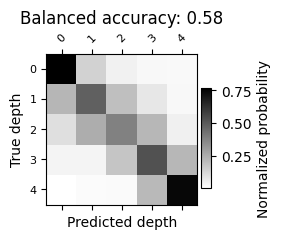

In [42]:
templabels = [str(int(ii)) for ii in np.unique(merged_labels).tolist()]
fig, ax = plt.subplots(figsize=(2,2))
im = ax.matshow(overall_cm/np.sum(overall_cm, axis=1, keepdims=True), cmap='gray_r')
ax.set_xticks(np.arange(overall_cm.shape[0]).tolist())
ax.set_xticklabels(templabels, rotation=45, fontsize=8)
ax.set_yticks(np.arange(overall_cm.shape[0]).tolist())
ax.set_yticklabels(templabels, fontsize=8)
ax.set_xlabel('Predicted depth')
ax.set_ylabel('True depth')
ax.set_title(f'Balanced accuracy: {np.mean(nested_scores):.2f}')
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.2, 0.05, 0.5])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.2, 0.05, 0.5])
fig.colorbar(im, cax=cax)
cax.set_ylabel('Normalized probability')
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_depth.svg")

## On-Off index - explicit readout

In [72]:
feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


<All keys matched successfully>

In [82]:
# Note that 28188-18-4 does not have responses to chirp and moving_bar
all_clusterID, all_features_np = [], []
for ii,datakey in enumerate(datakeys[:]):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_info[
        (all_cluster_info['animal_id'] == int(animal_id_str)) &
        (all_cluster_info['session_id'] == int(session_id_str)) &
        (all_cluster_info['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'on_off_idx'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    features_np = factorised_3d_model.readout[datakey].features.detach().cpu().numpy().squeeze().transpose()
    features_np = features_np[indices_in_unit_ids,:]
    print (f'datakey: {datakey}, clusterID.shape: {clusterID.shape}, features_np.shape: {features_np.shape}')
    all_clusterID.append(clusterID)
    all_features_np.append(features_np)
all_on_off_idx = np.hstack(all_clusterID)
all_features_np = np.vstack(all_features_np)
print (f'all_on_off_idx.shape: {all_on_off_idx.shape}, all_features_np.shape: {all_features_np.shape}')

datakey: dynamic29163-4-4-Fluorescence-7b721b-v4a, clusterID.shape: (3033,), features_np.shape: (3033, 64)
datakey: dynamic28188-18-4-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28712-3-8-Fluorescence-7b721b-v4a, clusterID.shape: (1271,), features_np.shape: (1271, 64)
datakey: dynamic29163-6-5-Fluorescence-7b721b-v4a, clusterID.shape: (1014,), features_np.shape: (1014, 64)
datakey: dynamic29163-5-8-Fluorescence-7b721b-v4a, clusterID.shape: (1051,), features_np.shape: (1051, 64)
datakey: dynamic28188-19-9-Fluorescence-7b721b-v4a, clusterID.shape: (636,), features_np.shape: (636, 64)
datakey: dynamic28188-17-2-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic29163-2-7-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-5-Fluorescence-7b721b-v4a, clusterID.shape: (0,), features_np.shape: (0, 64)
datakey: dynamic28188-16-3-Fluorescence-7b721b-v4a, cluster

(array([ 697.,  468.,  658.,  813., 1325., 1263.,  733.,  380.,  261.,
         407.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

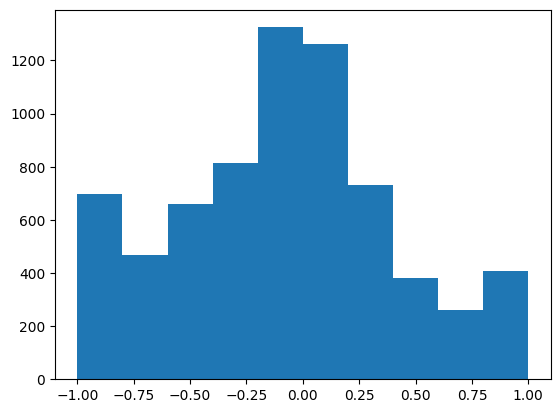

In [75]:
plt.hist(all_on_off_idx)

In [76]:
merged_labels = np.copy(all_on_off_idx)

In [77]:
XX, yy = np.copy(all_features_np), np.copy(merged_labels)

class RidgeWithActivation(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0, activation='tanh'):
        self.alpha = alpha
        self.activation = activation

    def fit(self, X, y):
        self.regressor_ = Ridge(alpha=self.alpha)  # Use underscore to mark fitted attribute
        self.regressor_.fit(X, y)
        return self

    def predict(self, X):
        y_pred = self.regressor_.predict(X)
        return self._apply_activation(y_pred)

    def _apply_activation(self, y_pred):
        if self.activation == 'tanh':
            return np.tanh(y_pred)
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-y_pred))
        else:
            raise ValueError("Unsupported activation. Choose 'tanh' or 'sigmoid'.")

# class RidgeWithActivation(BaseEstimator, RegressorMixin):
#     def __init__(self, alpha=1.0, activation='tanh'):
#         self.alpha = alpha
#         self.activation = activation
#         self.regressor = Ridge(alpha=self.alpha) # Ridge # Lasso
#     def fit(self, X, y):
#         self.regressor.fit(X, y)
#         return self
#     def predict(self, X):
#         y_pred = self.regressor.predict(X)
#         return self._apply_activation(y_pred)
#     def _apply_activation(self, y_pred):
#         if self.activation == 'tanh':
#             return np.tanh(y_pred)  # Apply tanh activation
#         elif self.activation == 'sigmoid':
#             return 1 / (1 + np.exp(-y_pred))  # Apply sigmoid activation
#         else:
#             raise ValueError("Unsupported activation. Choose 'tanh' or 'sigmoid'.")

# Create pipeline for feature scaling and regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('regressor', RidgeWithActivation()),           # Ridge regression
])

# Define parameter grid for inner loop (hyperparameter tuning)
param_grid = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]} # Ridge regularization parameter 
# Outer loop (10-fold cross-validation); for imbalanced data
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# To store results
nested_scores = []
y_tests, y_preds = [], []
# Perform nested cross-validation
for train_idx, test_idx in outer_cv.split(XX): # 
    # Split data into training and test sets for the outer loop
    X_train, X_test = XX[train_idx], XX[test_idx]
    y_train, y_test = yy[train_idx], yy[test_idx]
    # Inner loop: Perform hyperparameter tuning using GridSearchCV
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV for tuning
    mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring=mse_scorer, 
        verbose=1,  # 0
    )
    # Fit GridSearchCV on the training data from the outer loop
    grid_search.fit(X_train, y_train)
    # Best model from the inner loop
    best_model = grid_search.best_estimator_  # grid_search.best_params_
    
    # Evaluate the best model on the outer loop test set
    y_pred = best_model.predict(X_test)
    outer_score = mean_squared_error(y_test, y_pred)
    nested_scores.append(outer_score)
    y_tests.append(y_test)
    y_preds.append(y_pred)

# Report nested cross-validation results
print("Nested CV Accuracy Scores:", nested_scores)
print("Mean Accuracy:", np.mean(nested_scores))
print("Standard Deviation:", np.std(nested_scores))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Nested CV Accuracy Scores: [0.11806054734472031, 0.09703367621905891, 0.1117901912183796, 0.0912514582880262, 0.10058265199773403, 0.11668326019468357, 0.09922840191697618, 0.10949060583473046, 0.11991703878213628, 0.11765470470835061]
Mean Accuracy: 0.10816925365047962
Standard Deviation: 0.009802426409474936


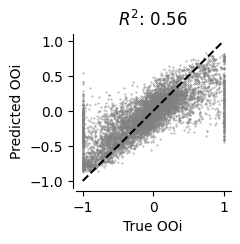

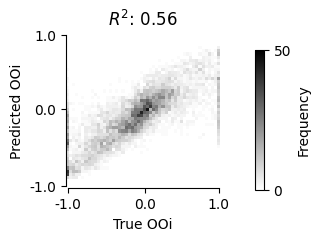

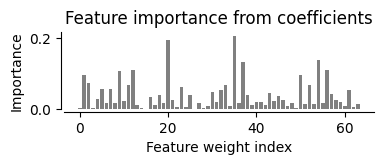

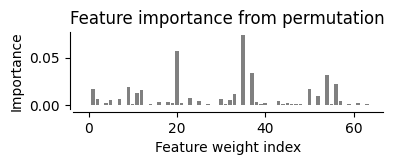

In [83]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.scatter(np.hstack(y_tests), np.hstack(y_preds), s=0.1, color='gray')
# plt.scatter(y_test, y_pred)
ax.plot((-1,1),(-1,1), c='k', linestyle='--')
ax.set_xlabel('True OOi')
ax.set_ylabel('Predicted OOi')
ax.set_title(r'$R^2$' + f': {r2_score(np.hstack(y_tests), np.hstack(y_preds)):.2f}')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_on_off_idx.svg")

hist_range = [[-1.0, 1.0], [-1.0, 1.0]]
bins = 50
show_min = 0
show_max = 50 # 0.006
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2))
x, y = np.hstack(y_tests), np.hstack(y_preds)
weights = np.ones_like(x) # /float(len(x))
hist_data, _, _ = np.histogram2d(x, y, bins=bins, range=hist_range, weights=weights)
hist_data = hist_data.T
im = ax.imshow(hist_data, interpolation='nearest', origin='lower',cmap='gray_r',vmin=show_min, vmax=show_max) # jet, viridis
ax.set_xlabel('True OOi')
ax.set_ylabel('Predicted OOi')
ax.set_title(r'$R^2$' + f': {r2_score(x, y):.2f}')
#
ax.set_xticks([0, int(bins/2), bins-1])
ax.set_xticklabels([hist_range[0][0], np.sum(hist_range[0])/2, hist_range[0][1]])
ax.set_yticks([0, int(bins/2), bins-1])
ax.set_yticklabels([hist_range[1][0], np.sum(hist_range[1])/2, hist_range[1][1]])
#
sns.despine(trim=True)
fig.subplots_adjust(right=0.83)
cbar_ax = fig.add_axes([0.85, 0.1, 0.03, 0.7])
ticks=[show_min, show_max]
cbar = fig.colorbar(im, cax=cbar_ax, ticks=ticks)
cbar.set_label("Frequency")
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_on_off_idx.svg")

# Get the absolute importance for a single-class (binary) model or average for multiclass
feature_importance = np.abs(best_model.named_steps['regressor'].regressor_.coef_)
#
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (4,1))
ax.bar(range(len(feature_importance)), feature_importance, color='gray')
ax.set_xlabel('Feature weight index')
ax.set_ylabel('Importance')
ax.set_title('Feature importance from coefficients')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_on_off_idx_importance_coefficient.svg")

# Feature Importance from Permutation
result = permutation_importance(best_model, X_test, y_test, scoring=mse_scorer) 
#
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (4,1))
ax.bar(range(X_test.shape[1]), result.importances_mean, color='gray')
ax.set_xlabel('Feature weight index')
ax.set_ylabel('Importance')
ax.set_title('Feature importance from permutation')
adjust_spines(ax, ['left', 'bottom'])
# plt.savefig(f"out_result/explicit_readout_feature_weight_predict_on_off_idx_importance_permutation.svg")

## PCA on feature weights - explicit readout

In [84]:
from sklearn.decomposition import PCA
def pca_on_data_split(responses_train, responses_val, n_components=2):
    """
    PCA
    
    Args:
        responses_train: 2D numpy array, shape: (num_of_samples, num_of_neurons), 
                         the pca would be applied on the second axis (features),
                         this is for training the PCA
                         
    Return:
        
    """
    # print (f'responses_train.shape: {responses_train.shape}') # shape: S X N
    responses_train_mean = np.mean(responses_train, axis=0, keepdims=True)
    responses_train_centered = responses_train - responses_train_mean
    pca = PCA(n_components=n_components)
    pca.fit(responses_train_centered)

    # print (f'responses_val.shape: {responses_val.shape}') # shape: S X N
    responses_val_centered = responses_val - responses_train_mean
    responses_val_pca = pca.transform(responses_val_centered)
    # print (f'responses_val_pca.shape: {responses_val_pca.shape}') # shape: S X n_components
    responses_val_recon = pca.inverse_transform(responses_val_pca)
    responses_val_recon += responses_train_mean
    # print (f'responses_val_recon.shape: {responses_val_recon.shape}') # shape: S X N
    
    # corrs = -2.0 * np.ones((responses_val.shape[1],))
    # for ii in range(len(corrs)):
    #     corrs[ii], _ = pearsonr(responses_val[:,ii], responses_val_recon[:,ii])
    # # print (f'np.mean(corrs): {np.mean(corrs)}')
    # corr = np.mean(corrs)
    return responses_val_pca, responses_val_recon

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(


dynamic29163-4-4-Fluorescence-7b721b-v4a
features_np.shape: (3175, 64)
features_pca.shape: (3175, 2)
features_recon.shape: (3175, 64)
dynamic28188-18-4-Fluorescence-7b721b-v4a
features_np.shape: (1593, 64)
features_pca.shape: (1593, 2)
features_recon.shape: (1593, 64)
dynamic28712-3-8-Fluorescence-7b721b-v4a
features_np.shape: (1728, 64)
features_pca.shape: (1728, 2)
features_recon.shape: (1728, 64)
dynamic29163-6-5-Fluorescence-7b721b-v4a
features_np.shape: (1079, 64)
features_pca.shape: (1079, 2)
features_recon.shape: (1079, 64)
dynamic29163-5-8-Fluorescence-7b721b-v4a
features_np.shape: (1113, 64)
features_pca.shape: (1113, 2)
features_recon.shape: (1113, 64)
dynamic28188-19-9-Fluorescence-7b721b-v4a
features_np.shape: (787, 64)
features_pca.shape: (787, 2)
features_recon.shape: (787, 64)
dynamic28188-17-2-Fluorescence-7b721b-v4a
features_np.shape: (1714, 64)
features_pca.shape: (1714, 2)
features_recon.shape: (1714, 64)
dynamic29163-2-7-Fluorescence-7b721b-v4a
features_np.shape: (1

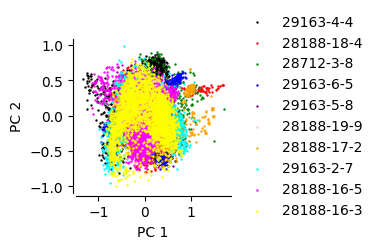

In [85]:
# datakey = list(data_loaders['train'].keys())[1]
# datakey2 = list(data_loaders['train'].keys())[0]

feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))
fig, ax = plt.subplots(figsize=(2,2))
colors = ['k', 'r', 'g', 'b', 'purple', 'pink', 'orange', 'cyan', 'magenta', 'yellow']
for ii in range(len(colors)):
    print (f'{datakeys[ii]}')
    features_np = factorised_3d_model.readout[datakeys[ii]].features.detach().cpu().numpy()
    features_np = np.transpose(np.squeeze(features_np), (1,0))
    print (f'features_np.shape: {features_np.shape}')
    n_components = 2
    features_pca, features_recon = pca_on_data_split(features_np, features_np, n_components=n_components)
    print (f'features_pca.shape: {features_pca.shape}')
    print (f'features_recon.shape: {features_recon.shape}')
    ax.scatter(features_pca[:,0], features_pca[:,1], s=0.5, c=colors[ii], label=datakeys[ii][7:-24])
    
    # feature_latent_np = factorised_3d_model.readout[datakeys[ii]].feature_latent.detach().cpu().numpy()
    # ax.scatter(feature_latent_np[:,0], feature_latent_np[:,1], s=0.5, c=colors[ii], label=datakeys[ii][7:-24])
# feature_latent_np = factorised_3d_model.readout[datakey2].feature_latent.detach().cpu().numpy()
# ax.scatter(feature_latent_np[:,0], feature_latent_np[:,1], s=0.2, c='g', label='Session 2')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
# ax.set_xlim((-1,1))
# ax.legend()
# ax.set_title(f'Implicit readout')
# plt.tight_layout()
adjust_spines(ax, ['left', 'bottom'])
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles, labels, loc='center left', frameon=False,bbox_to_anchor=(1, 0.5))
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA_2PCs_scatter_plot_scan.svg")

/mnt/scratch09/yongrong/projects/supcol/src/neuralpredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/tmp/ipykernel_1647/69699684.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=45)
/tmp/ipykernel_1647/69699684.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(templabels, rotation=45)


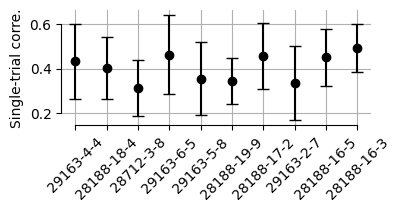

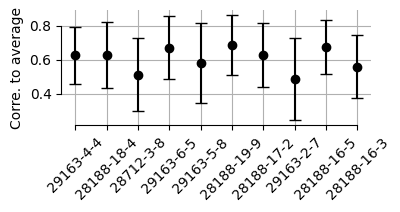

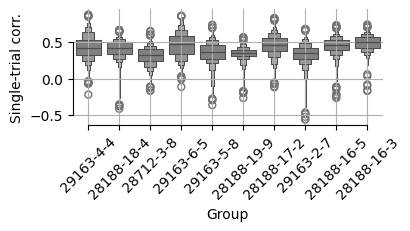

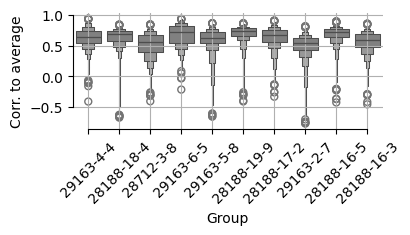

In [65]:
# CC for model_copy with features_recon
import copy

feature_latent_flags = [False]
unit_speed_flag = False
position_encoding_flag = False
wandb_suffixes = ['v05aa']

tempmodelfile = './out/' + 'data_retina_sc_multiple_v4a_fluor_model_fac3d_seed_111_' + wandb_suffixes[0] + '.pth' 
factorised_3d_model = make_video_model(
    data_loaders,
    seed,
    core_dict=factorised_3D_core_dict,
    core_type='3D_factorised',
    readout_dict=readout_dict.copy(),
    readout_type='gaussian',               
    use_gru=False,
    gru_dict=None,
    use_shifter=True,
    shifter_dict=shifter_dict,
    shifter_type='MLP',
    feature_latent_flag=feature_latent_flags[0], # True # False
    feature_latent_dim=2,
    position_encoding_flag=position_encoding_flag,
    position_encoding_k=16,
)
factorised_3d_model.load_state_dict(torch.load(tempmodelfile, weights_only=True))

# model_copy with features_recon
model_copy = copy.deepcopy(factorised_3d_model)
for ii in range(len(datakeys)):
    features_np = factorised_3d_model.readout[datakeys[ii]].features.detach().cpu().numpy()
    features_np = np.transpose(np.squeeze(features_np), (1,0))
    n_components = 2
    features_pca, features_recon = pca_on_data_split(features_np, features_np, n_components=n_components)
    model_copy.readout[datakeys[ii]].features.data = torch.from_numpy(np.transpose(features_recon[None,:, None,:], (0,3,2,1))).to(device)

model_copy.eval()
evaluation_hashes_unique, single_trial_corrs, mean_corrs = get_signal_correlations(
    model_copy, data_loaders, tier='test', stimulus_type='clip', 
    evaluation_hashes_unique=[
    "5zQTb77qI+ig8rigx1XU",
    "7UETOWO5Z8aWuHDBJ2GG",
    "GjCMo2GkJp6y5vricadg",
    "KXdTNAGMo1gCWz2Ge8zr",
    "Oup5uAZxF2G7zEJkT+ui",
    "ecUQJtcERZJGdqza1k7h",
    ],
    device=device, as_dict=True, per_neuron=True
)

templabels = [datakey[7:-24] for datakey in datakeys]
temp_means = [np.mean(single_trial_corrs[datakey]) for datakey in datakeys]
temp_stds = [np.std(single_trial_corrs[datakey], ddof=1) for datakey in datakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
            marker='o', color='k',linestyle='None',alpha=1, capsize=4)
ax.set_xticks(np.arange(len(temp_means)).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,5.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=45)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Single-trial corre.')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA_2PCs_single_corr.svg")

temp_means = [np.mean(mean_corrs[datakey]) for datakey in datakeys]
temp_stds = [np.std(mean_corrs[datakey], ddof=1) for datakey in datakeys]
fig,ax=plt.subplots(nrows=1, ncols=1,figsize=(4,1.5))
ax.errorbar(np.arange(len(templabels)),temp_means,yerr=temp_stds,\
            marker='o', color='k',linestyle='None',alpha=1, capsize=4)
ax.set_xticks(np.arange(len(temp_means)).tolist())
# ax.set_yticks([0.45,0.55,0.65])
# ax.set_ylim(ymin=0.5)
# ax.set_xlim([-0.5,5.5])
ax.grid(True)
# adjust_spines(ax, ['left', 'bottom'])
ax.set_xticklabels(templabels, rotation=45)
# ax.set_xlabel('Model readout')
ax.set_ylabel('Corre. to average')
sns.despine(trim=True)
# plt.tight_layout()
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA_2PCs_ave_corr.svg")

records = []
for i, datakey in enumerate(datakeys):
    for val in single_trial_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=45)
ax.set_ylabel("Single-trial corr.")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA_2PCs_single_corr.svg")

records = []
for i, datakey in enumerate(datakeys):
    for val in mean_corrs[datakey]:
        records.append({"Group": templabels[i], "Value": val})
df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(4, 1.5))
# seaborn boxenplot
sns.boxenplot(
    data=df,
    x="Group",
    y="Value",
    color="gray",
    ax=ax
)
# axis formatting
ax.set_xticklabels(templabels, rotation=45)
ax.set_ylabel("Corr. to average")
ax.grid(True)
sns.despine(trim=True)
# plt.savefig(f"out_result/explicit_readout_feature_weight_PCA_2PCs_ave_corr.svg")

Text(0, 0.5, 'Depth')

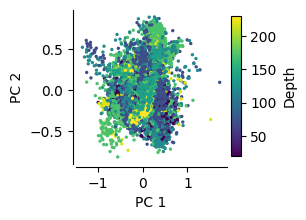

In [66]:
# # Combine multiple Matplotlib colormaps
# set3_colors = plt.get_cmap('Set3').colors
# paired_colors = plt.get_cmap('Paired').colors
# accent_colors = plt.get_cmap('Accent').colors
# # Concatenate colors and limit to 50
# combined_colors = list(set3_colors) + list(paired_colors) + list(accent_colors)
# custom_cmap = ListedColormap(combined_colors[:50])

# # import seaborn as sns
# # custom_cmap = ListedColormap(sns.husl_palette(50).as_hex())
custom_cmap = plt.get_cmap('viridis') # viridis

features_pca_s = []
clusterID_s = []
for ii,datakey in enumerate(datakeys):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_info[
        (all_cluster_info['animal_id'] == int(animal_id_str)) &
        (all_cluster_info['session_id'] == int(session_id_str)) &
        (all_cluster_info['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'depth'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # feature_latent_np = factorised_3d_model.readout[datakey].feature_latent.detach().cpu().numpy()
    features_np = factorised_3d_model.readout[datakeys[ii]].features.detach().cpu().numpy()
    features_np = np.transpose(np.squeeze(features_np), (1,0))
    n_components = 3
    features_pca, features_recon = pca_on_data_split(features_np, features_np, n_components=n_components)
    features_pca_s.append(features_pca[indices_in_unit_ids,:])
    clusterID_s.append(clusterID)
features_pca_s = np.vstack(features_pca_s)
clusterID_s = np.hstack(clusterID_s)
fig, ax = plt.subplots(figsize=(2, 2))  # adjust figsize as needed
im = ax.scatter(features_pca_s[:, 0], 
                features_pca_s[:, 1], 
                s=2, 
                c=clusterID_s, 
                cmap=custom_cmap)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
# ax.set_xticks([-0.5, 0, 0.5])
# ax.set_yticks([-0.5, 0, 0.5])
adjust_spines(ax, ['left', 'bottom'])
# Add colorbar with adjusted label
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.9, 0.15, 0.05, 0.7])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.15, 0.05, 0.7])
# fig.colorbar(im, cax=cax, ticks=np.arange(np.min(clusterID_sorted), np.max(clusterID_sorted) + 1))
fig.colorbar(im, cax=cax)
cax.set_ylabel('Depth')
# plt.savefig(f"out_result/implicit_readout_latents_depth.svg")

In [67]:
# import plotly.graph_objects as go

# # Create interactive 3D scatter plot
# fig = go.Figure(data=[go.Scatter3d(
#     x=features_pca_s[:, 0],
#     y=features_pca_s[:, 1],
#     z=features_pca_s[:, 2],
#     mode='markers',
#     marker=dict(
#         size=2,
#         color=clusterID_s,              # Color by cluster ID
#         colorscale='Viridis',           # Change to custom_cmap if available in Plotly format
#         colorbar=dict(title='Depth'),   # Add colorbar
#         showscale=True
#     )
# )])

# fig.update_layout(
#     scene=dict(
#         xaxis_title='PC 1',
#         yaxis_title='PC 2',
#         zaxis_title='PC 3',
#     ),
#     margin=dict(l=0, r=0, b=0, t=0)
# )

# fig.show()


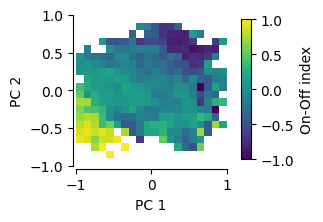

In [101]:
# # Combine multiple Matplotlib colormaps
# set3_colors = plt.get_cmap('Set3').colors
# paired_colors = plt.get_cmap('Paired').colors
# accent_colors = plt.get_cmap('Accent').colors
# # Concatenate colors and limit to 50
# combined_colors = list(set3_colors) + list(paired_colors) + list(accent_colors)
# custom_cmap = ListedColormap(combined_colors[:50])

# # import seaborn as sns
# # custom_cmap = ListedColormap(sns.husl_palette(50).as_hex())
custom_cmap = plt.get_cmap('viridis') # viridis

features_pca_s = []
clusterID_s = []
for ii,datakey in enumerate(datakeys):
    # Regular expression to extract the desired animal_id, session_id, scan_id
    pattern = r'dynamic(\d+)-(\d+)-(\d+)-'
    (animal_id_str, session_id_str, scan_id_str) = re.search(pattern, datakey).groups()
    filtered_data = all_cluster_info[
        (all_cluster_info['animal_id'] == int(animal_id_str)) &
        (all_cluster_info['session_id'] == int(session_id_str)) &
        (all_cluster_info['scan_id'] == int(scan_id_str))
    ]
    # extract the desired unit_id
    cluster_unit_ids = filtered_data.loc[:, 'unit_id'].values
    unit_ids = data_loaders['train'][datakey].dataset.neurons.unit_ids
    common_elements = np.intersect1d(unit_ids, cluster_unit_ids)
    filtered_data = filtered_data[filtered_data['unit_id'].isin(common_elements)]
    clusterID = filtered_data.loc[:, 'on_off_idx'].values
    
    indices_in_unit_ids = np.isin(unit_ids, common_elements)
    # feature_latent_np = factorised_3d_model.readout[datakey].feature_latent.detach().cpu().numpy()
    features_np = factorised_3d_model.readout[datakeys[ii]].features.detach().cpu().numpy()
    features_np = np.transpose(np.squeeze(features_np), (1,0))
    n_components = 2
    features_pca, features_recon = pca_on_data_split(features_np, features_np, n_components=n_components)
    features_pca_s.append(features_pca[indices_in_unit_ids,:])
    clusterID_s.append(clusterID)
features_pca_s = np.vstack(features_pca_s)
clusterID_s = np.hstack(clusterID_s)

# fig, ax = plt.subplots(figsize=(2, 2))  # adjust figsize as needed
# im = ax.scatter(features_pca_s[:, 0], 
#                 features_pca_s[:, 1], 
#                 s=2, 
#                 c=clusterID_s, 
#                 cmap=custom_cmap)
# ax.set_xlabel('PC 1')
# ax.set_ylabel('PC 2')
# # ax.set_xticks([-0.5, 0, 0.5])
# # ax.set_yticks([-0.5, 0, 0.5])
# adjust_spines(ax, ['left', 'bottom'])
# # Add colorbar with adjusted label
# fig.subplots_adjust(right=0.88)
# cax = fig.add_axes([0.9, 0.15, 0.05, 0.7])  # Adjust to fit within bounds
# # cax = fig.add_axes([1.02, 0.15, 0.05, 0.7])
# # fig.colorbar(im, cax=cax, ticks=np.arange(np.min(clusterID_sorted), np.max(clusterID_sorted) + 1))
# fig.colorbar(im, cax=cax)
# cax.set_ylabel('On-Off index')
# # plt.savefig(f"out_result/explicit_readout_PCA_on_off_index.svg")

xlim=(-1, 1)
ylim=(-1, 1)
heat_map = generate_2d_binned_average(features_pca_s, clusterID_s, bin_size=0.1, xlim=xlim, ylim=ylim)
fig, ax = plt.subplots(figsize=(2, 2))  # adjust figsize as needed
im = ax.imshow(heat_map.T, origin="lower", extent=[*xlim, *ylim],)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
# ax.set_xticks([-0.5, 0, 0.5])
# ax.set_yticks([-0.5, 0, 0.5])
adjust_spines(ax, ['left', 'bottom'])
# Add colorbar with adjusted label
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.95, 0.15, 0.05, 0.7])  # Adjust to fit within bounds
# cax = fig.add_axes([1.02, 0.15, 0.05, 0.7])
# fig.colorbar(im, cax=cax, ticks=np.arange(np.min(clusterID_sorted), np.max(clusterID_sorted) + 1))
fig.colorbar(im, cax=cax)
cax.set_ylabel('On-Off index')
# plt.savefig(f"out_result/explicit_readout_PCA_on_off_index.svg")